# Entrenamiento de un Modelo de ML para un Recomendador de Recetas

*Curso de Especialización en IA y Big Data 2025/2026*

<img src="https://drive.google.com/uc?id=1CDuZHOwG_fzbxaErUoIkzAS8xWGVg9II" width="150"/>


**Fecha**: 02/02/2026

**Alumnos**:

- Elías Robles Ruíz
- Cristina Vacas López
- Ruyi Xia Ye

[Link para ver el video explicatorio](https://youtu.be/QQojlJ8lJp0)

## **1. Introducción**

Este proyecto se centra en el desarrollo de un modelo de machine learning que se integrará en una aplicación de recomendación de recetas.

Durante el desarrollo y entrenamiento de este modelo, se utilizarán técnicas de procesamiento de lenguaje natural y análisis nutricional, así como algoritmos supervisados.

Y por último, en la interfaz de la aplicación se analizarán los datos del usuario como sexo, edad, peso, nivel de actividad física, constitución física y objetivo de peso (mantener, bajar o subir peso) para entender las preferencias del usuario y sugerir opciones personalizadas usando este modelo, asegurando que cada recomendación sea rápida, fácil y adaptada a las necesidades dietéticas.

## **2. Imports**

Importamos las librerías necesarias para nuestro proyecto.

In [431]:
import nltk
import json
import ast
import regex as re
import unicodedata
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datasets import load_dataset

from joblib import dump
from itertools import chain
from functools import lru_cache
from collections import Counter
from nltk.corpus import wordnet as wn

nltk.download("wordnet")
nltk.download("omw-1.4")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **3. Carga del dataset**

Link al dataset de HuggingFace [recipes-with-nutrition](https://huggingface.co/datasets/datahiveai/recipes-with-nutrition)

In [432]:
ds = load_dataset("datahiveai/recipes-with-nutrition")
df = ds["train"].to_pandas()

In [433]:
df.head(5)

,recipe_name,source,url,servings,calories,total_weight_g,image_url,diet_labels,health_labels,cautions,cuisine_type,meal_type,dish_type,ingredient_lines,ingredients,total_nutrients,daily_values,digest
0,Classic Cabbage Slaw with Grandmother Shinn's ...,Food Network,https://www.foodnetwork.com/recipes/classic-ca...,6.0,511.283250,1239.311259,https://datahive-prod-dataset-products.s3.eu-c...,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...",[],"[""american""]","[""lunch/dinner""]","[""salad""]","[""1 tablespoon kosher salt"",""2 cups water"",""4 ...","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":28...."
1,Black Bean Soup,Cookstr,http://www.cookstr.com/recipes/black-bean-soup...,8.0,1850.998990,3339.583230,https://datahive-prod-dataset-products.s3.eu-c...,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""Sulfites""]","[""american""]","[""lunch/dinner""]","[""soup""]","[""1 pound fully cooked bone-in ham steak"",""1 t...","[{""food"":""ham steak"",""text"":""1 pound fully coo...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":77...."
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,Serious Eats,http://www.seriouseats.com/recipes/2010/06/eat...,4.0,1643.758565,1453.960928,https://datahive-prod-dataset-products.s3.eu-c...,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""Gluten"",""Wheat"",""Sulfites""]","[""asian""]","[""lunch/dinner""]","[""main course""]","[""1 pound medium to firm tofu, cut into 1-inch...","[{""food"":""firm tofu"",""text"":""1 pound medium to...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":54...."
3,Fried Chicken Banh Mi,Food Network,https://www.foodnetwork.com/recipes/fried-chic...,4.0,8471.182075,2547.239375,https://datahive-prod-dataset-products.s3.eu-c...,"[""High-Fiber""]","[""Peanut-Free"",""Tree-Nut-Free"",""Fish-Free"",""Sh...","[""Gluten"",""Wheat"",""Sulfites""]","[""south east asian""]","[""lunch/dinner""]","[""sandwiches""]","[""Neutral oil, for frying"",""1/2 cup unseasoned...","[{""food"":""oil"",""text"":""Neutral oil, for frying...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":0,""..."
4,The Macaron Frappé,French Revolution Food,http://www.frenchrevolutionfood.com/2013/07/le...,1.0,276.243903,438.762998,https://datahive-prod-dataset-products.s3.eu-c...,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""Sulfites""]","[""french""]","[""snack""]","[""desserts""]","[""1 macaron (about ½ ounce), in any flavor you...","[{""food"":""macaron"",""text"":""1 macaron (about ½ ...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":47...."


## **4. Exploración y visualización del dataset**

Antes de limpiar el dataset, se lleva a cabo una etapa de exploración y visualización de los datos, para permitirnos comprender en profundidad la estructura del conjunto de datos, evaluar la calidad de la información y analizar la distribución de las distintas características.

### 4.1. Información general del dataset

In [434]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39447 entries, 0 to 39446
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   recipe_name       39447 non-null  object 
 1   source            39447 non-null  object 
 2   url               39447 non-null  object 
 3   servings          39447 non-null  float64
 4   calories          39447 non-null  float64
 5   total_weight_g    39447 non-null  float64
 6   image_url         39170 non-null  object 
 7   diet_labels       39447 non-null  object 
 8   health_labels     39447 non-null  object 
 9   cautions          39447 non-null  object 
 10  cuisine_type      39447 non-null  object 
 11  meal_type         39447 non-null  object 
 12  dish_type         39447 non-null  object 
 13  ingredient_lines  39447 non-null  object 
 14  ingredients       39447 non-null  object 
 15  total_nutrients   39447 non-null  object 
 16  daily_values      39447 non-null  object

La salida de `df.info()` nos proporciona una visión general del DataFrame:

* El conjunto de datos contiene **39.447 recetas (filas)** y **18 columnas**.

* Predominan las **variables de tipo texto (`object`)**, que representan información descriptiva y categórica como:

  * nombre de la receta (`recipe_name`)
  * fuente y URL (`source`, `url`)
  * etiquetas dietéticas y de salud (`diet_labels`, `health_labels`, `cautions`)
  * tipos culinarios (`cuisine_type`, `meal_type`, `dish_type`)
  * ingredientes y listas asociadas (`ingredient_lines`, `ingredients`)
  * información nutricional estructurada en formato texto (`total_nutrients`, `daily_values`, `digest`)

* Existen **3 variables numéricas (`float64`)**:

  * `servings`: número de porciones
  * `calories`: calorías totales de la receta
  * `total_weight_g`: peso total de la receta en gramos

* La gran mayoría de las columnas están **completas**, sin valores nulos.
  La única columna con valores faltantes es `image_url`, con una pequeña cantidad de registros nulos, lo que indica que algunas recetas no tienen imagen asociada.


### Resumen de columnas principales

| Columna            | Tipo    | Nulos | Descripción                                                   |
| ------------------ | ------- | ----- | ------------------------------------------------------------- |
| `recipe_name`      | object  | 0     | Nombre de la receta                                           |
| `source`           | object  | 0     | Fuente u origen de la receta                                  |
| `url`              | object  | 0     | Enlace web a la receta original                               |
| `servings`         | float64 | 0     | Número de porciones                                           |
| `calories`         | float64 | 0     | Calorías totales de la receta                                 |
| `total_weight_g`   | float64 | 0     | Peso total de la receta en gramos                             |
| `image_url`        | object  | 277   | URL de la imagen de la receta (puede faltar en algunos casos) |
| `diet_labels`      | object  | 0     | Etiquetas dietéticas (ej. low-carb, vegetarian)               |
| `health_labels`    | object  | 0     | Etiquetas relacionadas con la salud                           |
| `cautions`         | object  | 0     | Advertencias alimentarias (alérgenos, etc.)                   |
| `cuisine_type`     | object  | 0     | Tipo de cocina (italiana, mexicana, etc.)                     |
| `meal_type`        | object  | 0     | Tipo de comida (desayuno, comida, cena, snack)                |
| `dish_type`        | object  | 0     | Tipo de plato (sopa, ensalada, postre, etc.)                  |
| `ingredient_lines` | object  | 0     | Lista de ingredientes en formato textual                      |
| `ingredients`      | object  | 0     | Ingredientes estructurados                                    |
| `total_nutrients`  | object  | 0     | Información nutricional detallada (macros y micros)           |
| `daily_values`     | object  | 0     | Porcentajes de valores diarios recomendados                   |
| `digest`           | object  | 0     | Desglose nutricional por categorías                           |


### 4.2. Exploración de nulos

In [435]:
df.isna().sum()

,0
recipe_name,0
source,0
url,0
servings,0
calories,0
total_weight_g,0
image_url,277
diet_labels,0
health_labels,0
cautions,0


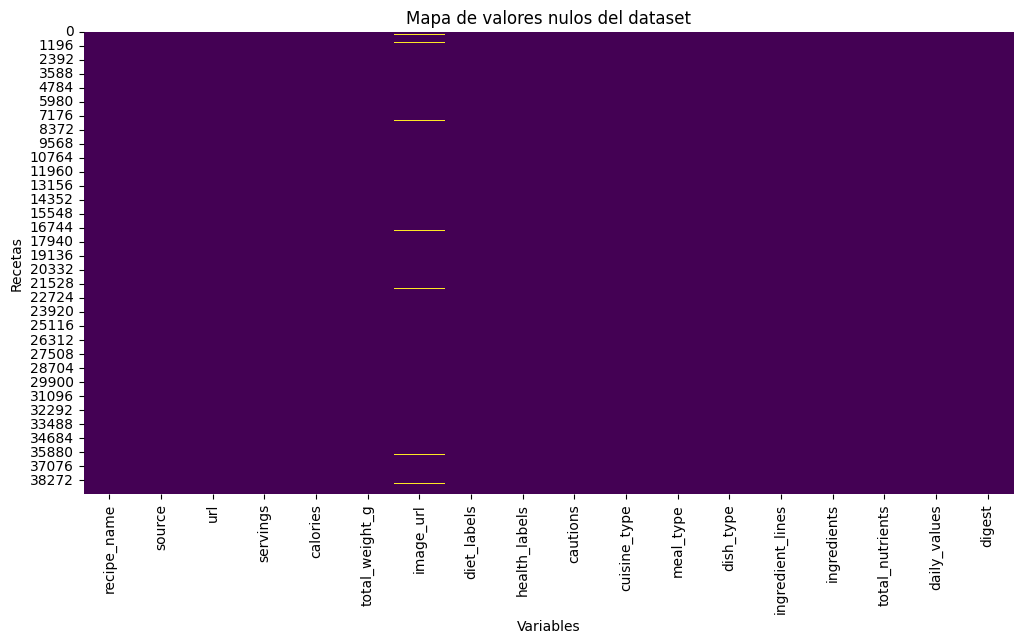

In [436]:
# Heatmap de valores nulos

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores nulos del dataset")
plt.xlabel("Variables")
plt.ylabel("Recetas")
plt.show()

Este heatmap de valores nulos nos ofrece una representación visual rápida de la integridad de los datos en el DataFrame.

Podemos ver claramente que el único campo con valores nulos es `image_url`.

### 4.3. Exploración de duplicados

In [437]:
# Recetas duplicadas
duplicados = df["recipe_name"].value_counts()
print(f"\nRecetas duplicadas (mismo nombre):")
print(duplicados[duplicados > 1])


Recetas duplicadas (mismo nombre):
recipe_name
Guacamole                        10
Greek Salad                       8
Butternut Squash Soup             8
Homemade Taco Seasoning           7
Garlic Mashed Potatoes            7
                                 ..
Sidecar Cocktail                  2
Avocado Deviled Eggs              2
Creamy Three-Cheese Spaghetti     2
Sofrito                           2
Rye Bread                         2
Name: count, Length: 896, dtype: int64


Podemos ver que existen bastantes recetas duplicadas (aquellas con el mismo nombre) en este dataset, unos **896 duplicados**. Más adelante, en la fase de limpieza del dataset eliminaremos estos duplicados para quedarnos solo con una instancia de cada receta única. Esto ayuda a evitar que el modelo de recomendación se sesgue o favorezca a recetas que aparecen múltiples veces, asegurando que cada receta tenga la misma oportunidad de ser recomendada.

### 4.4. Resumen estadístico

In [438]:
df.describe()

,servings,calories,total_weight_g
count,39447.000000,39447.000000,39447.000000
mean,7.564720,2139.060923,1286.781265
std,15.301538,1924.697195,984.708243
min,1.000000,0.060000,1.308594
25%,4.000000,866.158614,619.459835
50%,6.000000,1656.948000,1043.021171
75%,8.000000,2817.372416,1678.103922
max,1520.000000,33319.350000,7971.355779


El análisis de las columnas numéricas (`servings`, `calories` y `total_weight_g`) muestra una **alta variabilidad y presencia de valores extremos**.

* **Porciones (`servings`)**:
  La media es 7.6 y la mediana 6, pero el valor máximo (1.520) es claramente irrealista, lo que indica outliers que sesgan la distribución.

* **Calorías (`calories`)**:
  La media (2.139 kcal) es superior a la mediana (1.657 kcal), con valores mínimos cercanos a cero y máximos muy elevados (33.319 kcal), lo que sugiere datos atípicos o errores.

* **Peso total (`total_weight_g`)**:
  Presenta un rango amplio (de 1.3 g a casi 8 kg). Aunque algunos valores altos pueden ser plausibles, también conviene revisarlos.

Más adelante, tendremos que tratar los outliers en estas variables antes de realizar análisis o entrenar modelos, para evitar sesgos en los resultados.


## **5. Limpieza y normalización de campos**


### 5.1. Selección de columnas

Antes realizar la limpieza y procesamiento de los campos, seleccionaremos únicamente aquellos campos que necesitaremos para el entrenamiento del modelo y la aplicación final.

In [439]:
cols_valid = ["recipe_name", "image_url", "servings", "diet_labels", "health_labels", "dish_type", "meal_type",
              "ingredients", "calories", "total_nutrients"]
df = df[cols_valid].copy()

In [440]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,ingredients,calories,total_nutrients
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",511.283250,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
1,Black Bean Soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]","[{""food"":""ham steak"",""text"":""1 pound fully coo...",1850.998990,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]","[{""food"":""firm tofu"",""text"":""1 pound medium to...",1643.758565,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
3,Fried Chicken Banh Mi,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber""]","[""Peanut-Free"",""Tree-Nut-Free"",""Fish-Free"",""Sh...","[""sandwiches""]","[""lunch/dinner""]","[{""food"":""oil"",""text"":""Neutral oil, for frying...",8471.182075,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
4,The Macaron Frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]","[{""food"":""macaron"",""text"":""1 macaron (about ½ ...",276.243903,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."


### 5.2. Eliminación de nulos y duplicados

In [441]:
df.isna().sum()

,0
recipe_name,0
image_url,277
servings,0
diet_labels,0
health_labels,0
dish_type,0
meal_type,0
ingredients,0
calories,0
total_nutrients,0


In [442]:
df.dropna(inplace=True)
df.isna().sum()

,0
recipe_name,0
image_url,0
servings,0
diet_labels,0
health_labels,0
dish_type,0
meal_type,0
ingredients,0
calories,0
total_nutrients,0


In [443]:
df.shape

(39170, 10)

Se queda en **39170  registros** de los 39447 iniciales.

In [444]:
duplicados = df["recipe_name"].value_counts()
print(duplicados[duplicados > 1])

recipe_name
Guacamole                     9
Greek Salad                   8
Butternut Squash Soup         8
Homemade Taco Seasoning       7
Garlic Mashed Potatoes        7
                             ..
Warm Shrimp Salad             2
Blueberry Pancakes recipes    2
Sweet Potato Creme Brulee     2
Butternut Squash Puree        2
Edamame Hummus                2
Name: count, Length: 881, dtype: int64


In [445]:
df.drop_duplicates(["recipe_name"], inplace=True)

In [446]:
duplicados = df["recipe_name"].value_counts()
print(f"\nRecetas duplicadas después de eliminar duplicados:")
print(duplicados[duplicados > 1])


Recetas duplicadas después de eliminar duplicados:
Series([], Name: count, dtype: int64)


In [447]:
df.shape

(37986, 10)

El dataframe se queda en **37986 registros**.

### 5.3. Campo `total_nutrients`

Esta columna incluye la información de los macronutrientes (calorias, grasas, proteinas, carbohidratos...) de cada receta. Para que nuestro modelo pueda analizarlos correctamente, tendremos que extraerlos y crear nuevas columnas para cada macro.

In [448]:
# Observamos cómo son los valores
df["total_nutrients"].head()

,total_nutrients
0,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
1,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
2,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
3,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."
4,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit..."


El campo `total_nutrients` tiene formato de JSON.

#### 5.3.1. Extraemos los macronutrientes

In [449]:
def extraer_macronutrientes(total_nutrients):
    """
    Extrae los macronutrientes principales de total_nutrients.
    Retorna un diccionario con los valores numéricos.
    """
    # Inicializar valores por defecto
    macros = {
        'protein_g': 0.0,
        'fat_g': 0.0,
        'carbohydrates_g': 0.0,
        'fiber_g': 0.0,
        'sugar_g': 0.0,
        'sodium_mg': 0.0,
        'cholesterol_mg': 0.0,
        'saturated_fat_g': 0.0,
        'calories_kcal': 0.0
    }

    # Si es None o vacío, retornar valores por defecto
    if not total_nutrients:
        return macros

    # Convertir a dict si es string JSON
    if isinstance(total_nutrients, str):
        try:
            total_nutrients = json.loads(total_nutrients)
        except:
            return macros

    # Si no es un diccionario, retornar valores por defecto
    if not isinstance(total_nutrients, dict):
        return macros

    # Mapeo de claves comunes en diferentes formatos
    # El formato puede variar: "PROCNT", "protein", "Protein", etc.
    mapeo_nutrientes = {
        'protein_g': ['PROCNT', 'protein', 'Protein', 'PROT'],
        'fat_g': ['FAT', 'fat', 'Fat', 'Total Fat', 'total_fat'],
        'carbohydrates_g': ['CHOCDF', 'carbohydrates', 'Carbohydrates', 'carbs', 'CARB'],
        'fiber_g': ['FIBTG', 'fiber', 'Fiber', 'dietary_fiber'],
        'sugar_g': ['SUGAR', 'sugar', 'Sugar', 'sugars'],
        'sodium_mg': ['NA', 'sodium', 'Sodium', 'SODIUM'],
        'cholesterol_mg': ['CHOLE', 'cholesterol', 'Cholesterol', 'CHOL'],
        'saturated_fat_g': ['FASAT', 'saturated_fat', 'Saturated Fat', 'SAT_FAT'],
        'calories_kcal': ['ENERC_KCAL', 'calories', 'Calories', 'energy', 'Energy']
    }

    # Extraer valores
    for macro_key, posibles_claves in mapeo_nutrientes.items():
        for clave in posibles_claves:
            if clave in total_nutrients:
                valor = total_nutrients[clave]

                # Si el valor es un diccionario con 'quantity' o 'value'
                if isinstance(valor, dict):
                    if 'quantity' in valor:
                        macros[macro_key] = float(valor['quantity'])
                        break
                    elif 'value' in valor:
                        macros[macro_key] = float(valor['value'])
                        break
                # Si es directamente un número
                elif isinstance(valor, (int, float)):
                    macros[macro_key] = float(valor)
                    break
                # Si es un string numérico
                elif isinstance(valor, str):
                    try:
                        macros[macro_key] = float(valor)
                        break
                    except:
                        continue

    return macros

In [450]:
# Probamos con un ejemplo
if 'total_nutrients' in df.columns:
    ejemplo = df['total_nutrients'].iloc[0]
    print("Ejemplo de extracción:")
    print("\nOriginal:")
    print(ejemplo)
    print("\nExtraído:")
    macros_ejemplo = extraer_macronutrientes(ejemplo)
    for key, value in macros_ejemplo.items():
        print(f"{key}: {value}")

Ejemplo de extracción:

Original:
{"K":{"unit":"mg","label":"Potassium","quantity":1344.937282852889},"P":{"unit":"mg","label":"Phosphorus","quantity":378.2385},"CA":{"unit":"mg","label":"Calcium","quantity":316.2168927486673},"FE":{"unit":"mg","label":"Iron","quantity":4.986129792681675},"MG":{"unit":"mg","label":"Magnesium","quantity":93.09561258661114},"NA":{"unit":"mg","label":"Sodium","quantity":2866.73889543204},"ZN":{"unit":"mg","label":"Zinc","quantity":2.631569932961114},"FAT":{"unit":"g","label":"Fat","quantity":15.262045},"NIA":{"unit":"mg","label":"Niacin (B3)","quantity":2.399385000000001},"FAMS":{"unit":"g","label":"Monounsaturated","quantity":5.07333925},"FAPU":{"unit":"g","label":"Polyunsaturated","quantity":2.4362785},"RIBF":{"unit":"mg","label":"Riboflavin (B2)","quantity":0.75085},"THIA":{"unit":"mg","label":"Thiamin (B1)","quantity":0.346041},"VITC":{"unit":"mg","label":"Vitamin C","quantity":124.065},"VITD":{"unit":"µg","label":"Vitamin D","quantity":2},"CHOLE":{"u

In [451]:
# Aplicamos la extracción a todo el dataset
if "total_nutrients" in df.columns:

    # Aplicar la función de extracción
    macros_df = df["total_nutrients"].apply(extraer_macronutrientes).apply(pd.Series)

    # Agregar las columnas al dataframe original
    for col in macros_df.columns:
        df[col] = macros_df[col]

    print("\n✓ Macronutrientes extraídos exitosamente")
    print(f"\nNuevas columnas creadas: {list(macros_df.columns)}")

else:
    print("No se encontró el campo 'total_nutrients'")


✓ Macronutrientes extraídos exitosamente

Nuevas columnas creadas: ['protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'saturated_fat_g', 'calories_kcal']


In [452]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,ingredients,calories,total_nutrients,protein_g,fat_g,carbohydrates_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,saturated_fat_g,calories_kcal
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",511.283250,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",19.597500,15.262045,74.524150,12.633475,55.653280,2866.738895,386.160000,5.740132,511.283250
1,Black Bean Soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]","[{""food"":""ham steak"",""text"":""1 pound fully coo...",1850.998990,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",181.811980,55.539721,158.914882,56.502798,11.406618,12553.539068,317.514659,15.555026,1850.998990
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]","[{""food"":""firm tofu"",""text"":""1 pound medium to...",1643.758565,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",101.236576,102.616128,103.412350,24.691537,0.000000,2006.309099,0.000000,10.899882,1643.758565
3,Fried Chicken Banh Mi,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber""]","[""Peanut-Free"",""Tree-Nut-Free"",""Fish-Free"",""Sh...","[""sandwiches""]","[""lunch/dinner""]","[{""food"":""oil"",""text"":""Neutral oil, for frying...",8471.182075,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",203.312290,559.329245,662.326780,32.722800,0.000000,7959.661000,833.645000,0.000000,8471.182075
4,The Macaron Frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]","[{""food"":""macaron"",""text"":""1 macaron (about ½ ...",276.243903,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",6.581078,14.428496,30.106954,1.184913,26.559992,148.884705,41.240000,9.599727,276.243903


Podemos ver que después de la extracción hay 2 campos con los valores de las calorias: `calories` y `calories_kcal`. Eliminamos una para no meter ruido.

In [453]:
df.drop(["calories_kcal"], axis=1, inplace=True)
df.head(1)

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,ingredients,calories,total_nutrients,protein_g,fat_g,carbohydrates_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,saturated_fat_g
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",511.28325,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",19.5975,15.262045,74.52415,12.633475,55.65328,2866.738895,386.16,5.740132


#### 5.3.2. Resumen estadístico de los macros

In [454]:
df.describe()

,servings,calories,protein_g,fat_g,carbohydrates_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,saturated_fat_g
count,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000,37986.000000
mean,7.572573,2138.850401,81.877293,111.053858,207.263537,19.549223,59.527188,2549.128721,326.579825,37.781432
std,15.422970,1926.029746,100.797408,135.152056,231.962861,23.439809,136.279939,3507.771137,789.584995,56.533729
min,1.000000,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,867.352500,18.723630,27.523906,52.132358,4.086290,0.000000,596.747575,0.000000,3.608150
50%,6.000000,1656.812515,50.710416,72.529274,137.232898,13.289864,11.552790,1773.102067,97.811546,17.085911
75%,8.000000,2815.058582,107.008586,149.730735,285.062533,27.117481,48.296156,3442.073958,477.254078,51.086607
max,1520.000000,33319.350000,1510.004160,3174.883501,4764.166807,621.148472,3093.608000,261944.265807,117780.136506,1414.263930


Como se señaló previamente en el apartado **4.4 Resumen estadístico**, los valores de los macronutrientes resultan excesivamente altos en muchas recetas, al igual que los correspondientes a las raciones (`servings`). Esto sugiere que, además de la presencia de *outliers*, los macronutrientes no están expresados por ración. Por tanto, será necesario transformar estos valores para que se correspondan con el tamaño de una porción (`serving`).

In [455]:
cols = {
    "calories": "cals_per_serving",
    "protein_g": "protein_per_serving",
    "fat_g": "fat_per_serving",
    "carbohydrates_g": "carbs_per_serving",
    "fiber_g": "fiber_per_serving",
    "sugar_g": "sugar_per_serving"
}

for col, new_col in cols.items():
    df[new_col] = (df[col] / df["servings"]).round(2)

In [456]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,ingredients,calories,total_nutrients,...,sugar_g,sodium_mg,cholesterol_mg,saturated_fat_g,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",511.283250,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",...,55.653280,2866.738895,386.160000,5.740132,85.21,3.27,2.54,12.42,2.11,9.28
1,Black Bean Soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]","[{""food"":""ham steak"",""text"":""1 pound fully coo...",1850.998990,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",...,11.406618,12553.539068,317.514659,15.555026,231.37,22.73,6.94,19.86,7.06,1.43
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]","[{""food"":""firm tofu"",""text"":""1 pound medium to...",1643.758565,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",...,0.000000,2006.309099,0.000000,10.899882,410.94,25.31,25.65,25.85,6.17,0.00
3,Fried Chicken Banh Mi,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber""]","[""Peanut-Free"",""Tree-Nut-Free"",""Fish-Free"",""Sh...","[""sandwiches""]","[""lunch/dinner""]","[{""food"":""oil"",""text"":""Neutral oil, for frying...",8471.182075,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",...,0.000000,7959.661000,833.645000,0.000000,2117.80,50.83,139.83,165.58,8.18,0.00
4,The Macaron Frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]","[{""food"":""macaron"",""text"":""1 macaron (about ½ ...",276.243903,"{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantit...",...,26.559992,148.884705,41.240000,9.599727,276.24,6.58,14.43,30.11,1.18,26.56


Ahora podemos eliminar las columnas antigüas que contenían los macros.

In [457]:
df.drop(["calories", "total_nutrients", "protein_g", "fat_g", "carbohydrates_g", "fiber_g", "sugar_g", "sodium_mg", "cholesterol_mg", "saturated_fat_g"], axis=1, inplace=True)

In [458]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37986 entries, 0 to 39445
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   recipe_name          37986 non-null  object 
 1   image_url            37986 non-null  object 
 2   servings             37986 non-null  float64
 3   diet_labels          37986 non-null  object 
 4   health_labels        37986 non-null  object 
 5   dish_type            37986 non-null  object 
 6   meal_type            37986 non-null  object 
 7   ingredients          37986 non-null  object 
 8   cals_per_serving     37986 non-null  float64
 9   protein_per_serving  37986 non-null  float64
 10  fat_per_serving      37986 non-null  float64
 11  carbs_per_serving    37986 non-null  float64
 12  fiber_per_serving    37986 non-null  float64
 13  sugar_per_serving    37986 non-null  float64
dtypes: float64(7), object(7)
memory usage: 4.3+ MB


#### 5.3.3. Visualización de macros

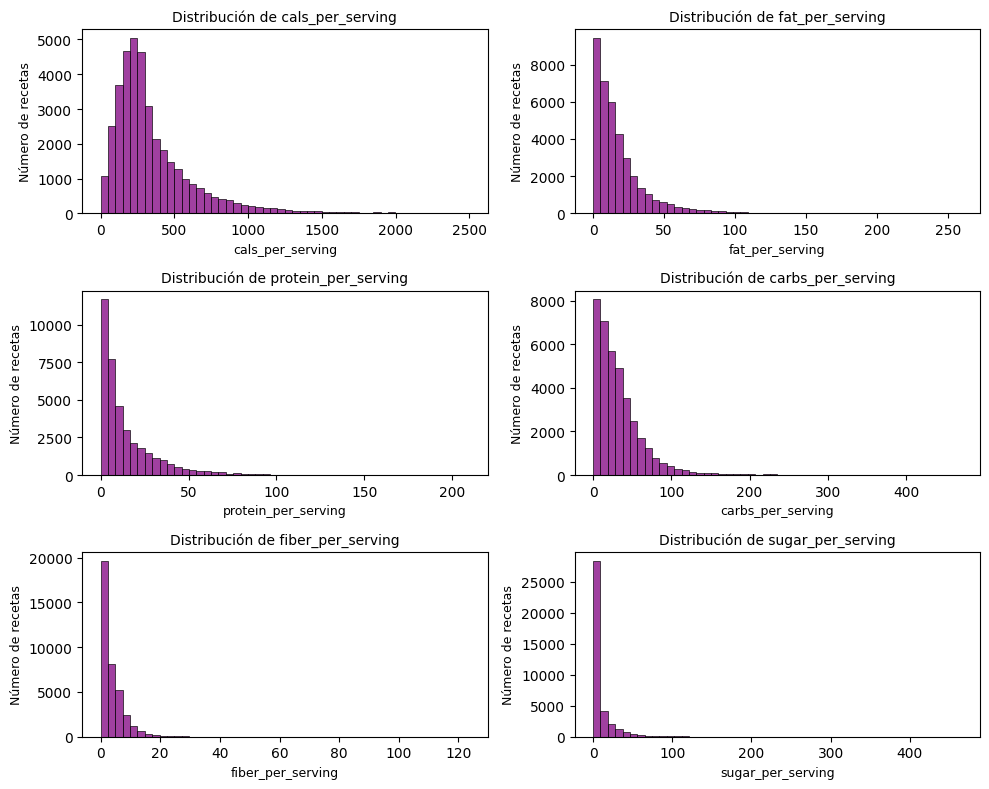

In [459]:
# Histograma de macronutrientes
nutrients = ["cals_per_serving", "fat_per_serving", "protein_per_serving", "carbs_per_serving", "fiber_per_serving", "sugar_per_serving", ]

# Creamos una figura con 2 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

# Aplanamos la matriz de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(nutrients):
    sns.histplot(df[col], bins=50, ax=axes[i], color="purple")

    axes[i].set_title(f"Distribución de {col}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Número de recetas", fontsize=9)

plt.tight_layout()
plt.show()

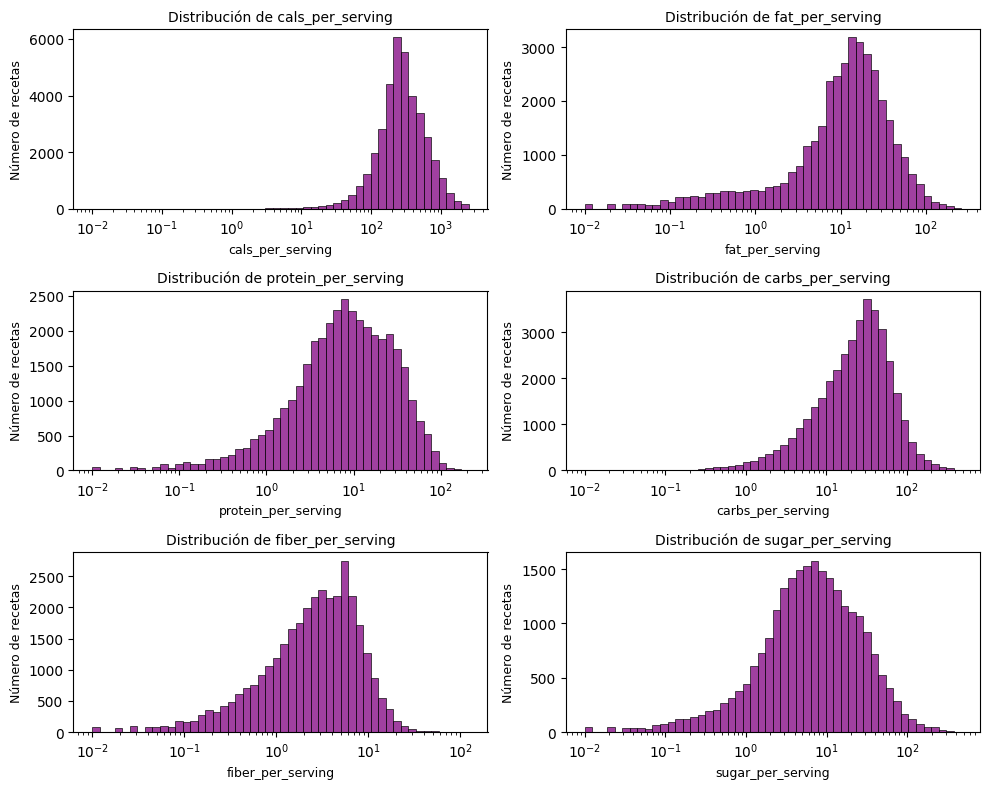

In [460]:
# Forma logaritmica
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

# Aplanamos la matriz de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(nutrients):
    sns.histplot(df[col], bins=50, ax=axes[i], log_scale=True, color="purple")

    axes[i].set_title(f"Distribución de {col}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Número de recetas", fontsize=9)

plt.tight_layout()
plt.show()

#### 5.3.4. Detección de inconsistencias nutricionales

In [461]:
# Valores nutricionales incoherentes (ej: Calories = 0 pero Protein/Carbs/Fat > 0)
incoherentes = df[(df["cals_per_serving"] == 0) &
                   ((df["protein_per_serving"] > 0) |
                    (df["fat_per_serving"] > 0) |
                    (df["carbs_per_serving"] > 0))]
print(f"\nRecetas con cals_per_serving=0 pero macros>0: {len(incoherentes)}")

if len(incoherentes) > 0:
    print(incoherentes[["recipe_name", "cals_per_serving", "protein_per_serving", "fat_per_serving", "carbs_per_serving"]])


Recetas con cals_per_serving=0 pero macros>0: 0


Parece que no hay inconsistencias de macronutrientes en las recetas.

In [462]:
# Valores nutricinales que no suman correctamente las calorías
# Nota: 1g proteína/carbs = 4 kcal, 1g grasa = 9 kcal (aproximado)
df["expected_calories"] = (df["protein_per_serving"] * 4 +
                            df["carbs_per_serving"] * 4 +
                            df["fat_per_serving"] * 9)
df["calorie_deviation"] = abs(df["cals_per_serving"] - df["expected_calories"]) / (df["cals_per_serving"] + 1)

print(f"\nDesviación promedio en calorías: {df["calorie_deviation"].mean():.2f}")
print(f"Recetas con desviación > 50%: {(df["calorie_deviation"] > 0.5).sum()}")


Desviación promedio en calorías: 0.06
Recetas con desviación > 50%: 891


- **Desviación promedio en calorías**: 0.06
  - Nos indica que, en general, el cálculo de calorías a partir de los macronutrientes (proteínas, carbohidratos y grasas) es bastante consistente con el valor de `Calories` reportado en el dataset. Una desviación promedio tan baja (6%) sugiere que la mayoría de las recetas tienen una buena coherencia nutricional.

- **Recetas con desviación > 50%**: 924
  - Aunque la desviación promedio es baja, hay un número significativo de 924 recetas donde las calorías calculadas difieren en más de un **50%** de las calorías reportadas. Esto apunta a la existencia de **valores atípicos** o **errores** importantes en los datos nutricionales de estas recetas específicas, que podrían requerir una limpieza o revisión más profunda, ya que podrían sesgar cualquier análisis o modelo que dependa de una alta precisión en los valores nutricionales.

#### 5.3.5. Eliminación de datos/valores incosistentes

In [463]:
# Aplicamos umbrales realistas basados en nutrición
df = df[
    (df["cals_per_serving"] > 0) & (df["cals_per_serving"] < 2000) &  # por serving
    (df["fat_per_serving"] >= 0) & (df["fat_per_serving"] < 200) &
    (df["carbs_per_serving"] >= 0) & (df["carbs_per_serving"] < 500) &
    (df["protein_per_serving"] >= 0) & (df["protein_per_serving"] < 200) &
    (df["servings"] > 0) & (df["servings"] <= 24)
].copy()

print(f"Filas después del filtrado: {len(df)}")
print(f"Estadísticas después del filtrado:")
print(df[["cals_per_serving", "fat_per_serving", "carbs_per_serving", "protein_per_serving", "servings"]].describe())

Filas después del filtrado: 36818
Estadísticas después del filtrado:
       cals_per_serving  fat_per_serving  carbs_per_serving  \
count      36818.000000     36818.000000       36818.000000   
mean         359.045959        18.250409          34.161650   
std          282.873835        19.999272          34.294207   
min            0.010000         0.000000           0.000000   
25%          180.372500         5.470000          11.460000   
50%          272.240000        12.710000          25.720000   
75%          449.245000        23.587500          45.220000   
max         1999.700000       198.220000         470.820000   

       protein_per_serving      servings  
count         36818.000000  36818.000000  
mean             14.769302      6.417045  
std              17.224977      4.395958  
min               0.000000      1.000000  
25%               3.520000      4.000000  
50%               8.350000      5.500000  
75%              20.060000      8.000000  
max             197

In [464]:
# Eliminamos aquellos registros con una desviación típica mayor del 50% en las calorias
df = df[df["calorie_deviation"] <= 0.5].copy()
print(f"Después de filtrar desviaciones altas: {len(df)} recetas")

Después de filtrar desviaciones altas: 35933 recetas


In [465]:
# Ahora podemos quitar las columnas de calorie_deviation y expected_calories
df.drop(["expected_calories", "calorie_deviation"], axis=1, inplace=True)

In [466]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35933 entries, 0 to 39445
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   recipe_name          35933 non-null  object 
 1   image_url            35933 non-null  object 
 2   servings             35933 non-null  float64
 3   diet_labels          35933 non-null  object 
 4   health_labels        35933 non-null  object 
 5   dish_type            35933 non-null  object 
 6   meal_type            35933 non-null  object 
 7   ingredients          35933 non-null  object 
 8   cals_per_serving     35933 non-null  float64
 9   protein_per_serving  35933 non-null  float64
 10  fat_per_serving      35933 non-null  float64
 11  carbs_per_serving    35933 non-null  float64
 12  fiber_per_serving    35933 non-null  float64
 13  sugar_per_serving    35933 non-null  float64
dtypes: float64(7), object(7)
memory usage: 4.1+ MB


### 5.4. Campo `ingredients`

In [467]:
df["ingredients"].head()

,ingredients
0,"[{""food"":""kosher salt"",""text"":""1 tablespoon ko..."
1,"[{""food"":""ham steak"",""text"":""1 pound fully coo..."
2,"[{""food"":""firm tofu"",""text"":""1 pound medium to..."
4,"[{""food"":""macaron"",""text"":""1 macaron (about ½ ..."
5,"[{""food"":""cabbage"",""text"":""1 cup cabbage, shre..."


Podemos ver que los valores que hay en el campo `ingredients` están en formato JSON. Tendremos que extraer los ingredientes al igual que los macros. También usaremos NLP para el parseo y normalización de los mismos.

#### 5.4.1. Extraemos los ingredientes

In [468]:
def limpiar_ingrediente(ingrediente):
    """
    Limpia un ingrediente del campo 'food'.
    Como estos ingredientes ya vienen sin cantidades ni medidas,
    solo necesitamos limpieza básica.
    """
    if not isinstance(ingrediente, str):
        return ""

    # Convertir a minúsculas y trim
    ingrediente = ingrediente.lower().strip()

    # Eliminar contenido entre paréntesis (información adicional)
    ingrediente = re.sub(r'\([^)]*\)', '', ingrediente)

    # Eliminar espacios múltiples
    ingrediente = re.sub(r'\s+', ' ', ingrediente).strip()

    # Eliminar guiones sueltos
    ingrediente = re.sub(r'\s*-\s*', ' ', ingrediente)
    ingrediente = re.sub(r'^-+|-+$', '', ingrediente)

    # Trim final
    ingrediente = ingrediente.strip()

    return ingrediente


def normalizar_nombre_compuesto(ingrediente):
    """
    Normaliza nombres de ingredientes compuestos y estandariza variaciones.
    """
    if not ingrediente:
        return ingrediente

    # Diccionario de normalizaciones
    normalizaciones = {
        # Aceites
        'extra virgin olive oil': 'olive oil',
        'virgin olive oil': 'olive oil',
        'evoo': 'olive oil',
        'canola oil': 'canola oil',
        'vegetable oil': 'vegetable oil',
        'coconut oil': 'coconut oil',
        'sesame oil': 'sesame oil',
        'peanut oil': 'peanut oil',
        'olive oil': 'olive oil',

        # Pimientos
        'green bell pepper': 'bell pepper',
        'red bell pepper': 'bell pepper',
        'yellow bell pepper': 'bell pepper',
        'orange bell pepper': 'bell pepper',
        'bell pepper': 'bell pepper',

        # Sales
        'kosher salt': 'salt',
        'sea salt': 'salt',
        'table salt': 'salt',
        'salt': 'salt',

        # Azúcares
        'granulated sugar': 'sugar',
        'white sugar': 'sugar',
        'caster sugar': 'sugar',
        'brown sugar': 'brown sugar',
        'light brown sugar': 'brown sugar',
        'dark brown sugar': 'brown sugar',
        'powdered sugar': 'powdered sugar',
        'confectioners sugar': 'powdered sugar',
        'icing sugar': 'powdered sugar',
        'sugar': 'sugar',

        # Harinas
        'all purpose flour': 'flour',
        'allpurpose flour': 'flour',
        'plain flour': 'flour',
        'whole wheat flour': 'whole wheat flour',
        'bread flour': 'bread flour',
        'flour': 'flour',

        # Caldos
        'chicken stock': 'chicken broth',
        'chicken broth': 'chicken broth',
        'beef stock': 'beef broth',
        'beef broth': 'beef broth',
        'vegetable stock': 'vegetable broth',
        'vegetable broth': 'vegetable broth',

        # Cremas
        'heavy cream': 'heavy cream',
        'heavy whipping cream': 'heavy cream',
        'whipping cream': 'heavy cream',
        'sour cream': 'sour cream',
        'cream cheese': 'cream cheese',

        # Salsas
        'soy sauce': 'soy sauce',
        'tamari': 'soy sauce',
        'tomato sauce': 'tomato sauce',
        'tomato paste': 'tomato paste',

        # Vinagres
        'apple cider vinegar': 'apple cider vinegar',
        'cider vinegar': 'apple cider vinegar',
        'white vinegar': 'white vinegar',
        'red wine vinegar': 'red wine vinegar',
        'white wine vinegar': 'white wine vinegar',
        'balsamic vinegar': 'balsamic vinegar',

        # Extractos
        'vanilla extract': 'vanilla extract',
        'pure vanilla extract': 'vanilla extract',
        'almond extract': 'almond extract',

        # Polvos y especias
        'baking powder': 'baking powder',
        'baking soda': 'baking soda',
        'garlic powder': 'garlic powder',
        'onion powder': 'onion powder',
        'chili powder': 'chili powder',
        'cayenne pepper': 'cayenne pepper',
        'black pepper': 'black pepper',
        'white pepper': 'white pepper',
        'dry mustard': 'mustard powder',
        'mustard powder': 'mustard powder',

        # Mantequillas
        'peanut butter': 'peanut butter',
        'unsalted butter': 'butter',
        'salted butter': 'butter',
        'butter': 'butter',

        # Jugos
        'lemon juice': 'lemon juice',
        'lime juice': 'lime juice',
        'orange juice': 'orange juice',

        # Vegetales comunes
        'green cabbage': 'cabbage',
        'red cabbage': 'cabbage',
        'cabbage': 'cabbage',
        'scallions': 'scallions',
        'green onions': 'scallions',
        'spring onions': 'scallions',

        # Huevos
        'eggs': 'eggs',
        'egg': 'eggs',

        # Agua
        'water': 'water',

        # Zanahorias
        'carrots': 'carrots',
        'carrot': 'carrots',
    }

    ingrediente_lower = ingrediente.lower().strip()

    # Buscar normalización exacta
    if ingrediente_lower in normalizaciones:
        return normalizaciones[ingrediente_lower]

    # Buscar si alguna clave está contenida en el ingrediente
    # Ordenar por longitud descendente para encontrar matches más específicos primero
    for clave in sorted(normalizaciones.keys(), key=len, reverse=True):
        if clave in ingrediente_lower:
            return normalizaciones[clave]

    return ingrediente


def procesar_ingredientes(lista_ingredientes):
    """
    Procesa una lista de ingredientes del campo 'food', limpiándolos y normalizándolos.
    """
    if not isinstance(lista_ingredientes, list):
        return []

    ingredientes_procesados = []

    for ingrediente in lista_ingredientes:
        if not isinstance(ingrediente, str):
            continue

        # Limpiar el ingrediente
        ingrediente_limpio = limpiar_ingrediente(ingrediente)

        # Si después de limpiar queda algo válido (más de 1 carácter)
        if ingrediente_limpio and len(ingrediente_limpio) > 1:
            # Normalizar nombres compuestos
            ingrediente_normalizado = normalizar_nombre_compuesto(ingrediente_limpio)

            # Verificar que no esté vacío después de normalizar
            if ingrediente_normalizado and ingrediente_normalizado.strip():
                ingredientes_procesados.append(ingrediente_normalizado.strip())

    return ingredientes_procesados



In [469]:
# Probamos con algunos ejemplos del campo 'food'
print("=== Ejemplos de procesamiento de ingredientes del campo 'food' ===\n")
ejemplos_food = [
    "kosher salt",
    "water",
    "green cabbage",
    "carrots",
    "scallions",
    "eggs",
    "apple cider vinegar",
    "granulated sugar",
    "dry mustard",
    "black pepper",
    "sour cream"
]

for ejemplo in ejemplos_food:
    limpio = limpiar_ingrediente(ejemplo)
    normalizado = normalizar_nombre_compuesto(limpio)
    print(f"Original:    {ejemplo:30s} → Normalizado: {normalizado}")
print("-" * 70)

=== Ejemplos de procesamiento de ingredientes del campo 'food' ===

Original:    kosher salt                    → Normalizado: salt
Original:    water                          → Normalizado: water
Original:    green cabbage                  → Normalizado: cabbage
Original:    carrots                        → Normalizado: carrots
Original:    scallions                      → Normalizado: scallions
Original:    eggs                           → Normalizado: eggs
Original:    apple cider vinegar            → Normalizado: apple cider vinegar
Original:    granulated sugar               → Normalizado: sugar
Original:    dry mustard                    → Normalizado: mustard powder
Original:    black pepper                   → Normalizado: black pepper
Original:    sour cream                     → Normalizado: sour cream
----------------------------------------------------------------------


In [470]:
# Aplicamos el procesamiento a todo el dataset
if 'ingredients' not in df.columns:
    print("ERROR: No se encontró la columna 'ingredients'")
    print("Columnas disponibles:", df.columns.tolist())
else:
    columna_ingredientes = 'ingredients'
    print(f"Procesando columna: {columna_ingredientes}")
    print(f"\nEjemplo antes de procesar:")
    print(df[columna_ingredientes].iloc[0])
    print(f"Tipo: {type(df[columna_ingredientes].iloc[0])}")

    # Función para extraer el campo 'food' de cada ingrediente
    def extraer_ingredientes_food(ingredientes):
        """
        Extrae el campo 'food' de cada ingrediente en el JSON.
        Espera una lista de diccionarios donde cada uno tiene un campo 'food'.
        """
        if not ingredientes:
            return []

        # Si es string, parsear como JSON
        if isinstance(ingredientes, str):
            try:
                ingredientes = json.loads(ingredientes)
            except:
                try:
                    import ast
                    ingredientes = ast.literal_eval(ingredientes)
                except:
                    return []

        # Si no es lista, retornar vacío
        if not isinstance(ingredientes, list):
            return []

        # Extraer el campo 'food' de cada ingrediente
        lista_food = []
        for ingrediente in ingredientes:
            if isinstance(ingrediente, dict) and 'food' in ingrediente:
                food = ingrediente['food']
                if food and isinstance(food, str):
                    lista_food.append(food)

        return lista_food

    # Primero extraer los valores de 'food' del JSON
    print("\nExtrayendo campo 'food' de cada ingrediente...")
    df['ingredients_food'] = df[columna_ingredientes].apply(extraer_ingredientes_food)

    # Luego procesar y limpiar los ingredientes extraídos
    print("Limpiando y normalizando ingredientes...")
    df['ingredients_clean'] = df['ingredients_food'].apply(procesar_ingredientes)

    print(f"\nEjemplo después de procesar:")
    print("Food extraídos:", df['ingredients_food'].iloc[0][:5])
    print("Limpios:", df['ingredients_clean'].iloc[0][:5])

    # Mostrar estadísticas
    print(f"\n--- Estadísticas ---")
    print(f"Total de recetas: {len(df)}")

    # Número promedio de ingredientes por receta
    num_ingredientes = df['ingredients_clean'].apply(len)
    print(f"Promedio de ingredientes por receta: {num_ingredientes.mean():.2f}")
    print(f"Mínimo de ingredientes: {num_ingredientes.min()}")
    print(f"Máximo de ingredientes: {num_ingredientes.max()}")


Procesando columna: ingredients

Ejemplo antes de procesar:
[{"food":"kosher salt","text":"1 tablespoon kosher salt","weight":14.56249999975379,"measure":"tablespoon","quantity":1},{"food":"water","text":"2 cups water","weight":473.176473,"measure":"cup","quantity":2},{"food":"green cabbage","text":"4 cups shredded green cabbage","weight":280,"measure":"cup","quantity":4},{"food":"carrots","text":"1 cup peeled and shredded carrots","weight":122,"measure":"cup","quantity":1},{"food":"scallions","text":"3/4 cup minced scallions","weight":75,"measure":"cup","quantity":0.75},{"food":"eggs","text":"2 large eggs","weight":100,"measure":"<unit>","quantity":2},{"food":"apple cider vinegar","text":"1/2 cup apple cider vinegar","weight":119.5,"measure":"cup","quantity":0.5},{"food":"granulated sugar","text":"3 tablespoons granulated sugar","weight":37.5,"measure":"tablespoon","quantity":3},{"food":"dry mustard","text":"1/2 teaspoon dry mustard","weight":1,"measure":"teaspoon","quantity":0.5},{"f

In [471]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,ingredients,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_food,ingredients_clean
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]","[{""food"":""kosher salt"",""text"":""1 tablespoon ko...",85.21,3.27,2.54,12.42,2.11,9.28,"[kosher salt, water, green cabbage, carrots, s...","[salt, water, cabbage, carrots, scallions, egg..."
1,Black Bean Soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]","[{""food"":""ham steak"",""text"":""1 pound fully coo...",231.37,22.73,6.94,19.86,7.06,1.43,"[ham steak, olive oil, onion, garlic, water, c...","[ham steak, olive oil, onion, garlic, water, c..."
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]","[{""food"":""firm tofu"",""text"":""1 pound medium to...",410.94,25.31,25.65,25.85,6.17,0.00,"[firm tofu, canola oil, scallions, piece of gi...","[firm tofu, canola oil, scallions, piece of gi..."
4,The Macaron Frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]","[{""food"":""macaron"",""text"":""1 macaron (about ½ ...",276.24,6.58,14.43,30.11,1.18,26.56,"[macaron, milk, vanilla ice cream, ice]","[macaron, milk, vanilla ice cream, ice]"
5,Cabbage au Gratin,https://datahive-prod-dataset-products.s3.eu-c...,2.0,"[""Low-Carb""]","[""Vegetarian"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""main course""]","[""lunch/dinner""]","[{""food"":""cabbage"",""text"":""1 cup cabbage, shre...",339.30,11.28,26.48,10.18,2.17,4.13,"[cabbage, unsalted butter, onion, garlic, drie...","[cabbage, butter, onion, garlic, dried thyme, ..."


In [472]:
df.drop(["ingredients_food", "ingredients"], axis=1, inplace=True)
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean
0,Classic Cabbage Slaw with Grandmother Shinn's ...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]",85.21,3.27,2.54,12.42,2.11,9.28,"[salt, water, cabbage, carrots, scallions, egg..."
1,Black Bean Soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]",231.37,22.73,6.94,19.86,7.06,1.43,"[ham steak, olive oil, onion, garlic, water, c..."
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]",410.94,25.31,25.65,25.85,6.17,0.00,"[firm tofu, canola oil, scallions, piece of gi..."
4,The Macaron Frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]",276.24,6.58,14.43,30.11,1.18,26.56,"[macaron, milk, vanilla ice cream, ice]"
5,Cabbage au Gratin,https://datahive-prod-dataset-products.s3.eu-c...,2.0,"[""Low-Carb""]","[""Vegetarian"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""main course""]","[""lunch/dinner""]",339.30,11.28,26.48,10.18,2.17,4.13,"[cabbage, butter, onion, garlic, dried thyme, ..."


#### 5.4.2. Visualización de `ingredients_clean`

In [473]:
# Análisis de ingredientes más comunes
print("=== Top 30 ingredientes más comunes ===\n")

# Crear un contador de todos los ingredientes
todos_ingredientes = []
for lista in df['ingredients_clean']:
    todos_ingredientes.extend(lista)

contador = Counter(todos_ingredientes)
top_ingredientes = contador.most_common(30)

for i, (ingrediente, cantidad) in enumerate(top_ingredientes, 1):
    print(f"{i:2d}. {ingrediente:30s} - {cantidad:6d} recetas ({cantidad/len(df)*100:5.2f}%)")

=== Top 30 ingredientes más comunes ===

 1. salt                           -  22962 recetas (63.90%)
 2. olive oil                      -  11187 recetas (31.13%)
 3. garlic                         -  10157 recetas (28.27%)
 4. butter                         -   9200 recetas (25.60%)
 5. sugar                          -   8164 recetas (22.72%)
 6. eggs                           -   8083 recetas (22.49%)
 7. water                          -   6939 recetas (19.31%)
 8. flour                          -   6450 recetas (17.95%)
 9. black pepper                   -   6282 recetas (17.48%)
10. pepper                         -   5787 recetas (16.10%)
11. onion                          -   4624 recetas (12.87%)
12. lemon juice                    -   3178 recetas ( 8.84%)
13. parsley                        -   3167 recetas ( 8.81%)
14. carrots                        -   2472 recetas ( 6.88%)
15. brown sugar                    -   2446 recetas ( 6.81%)
16. vanilla extract                -   2366 

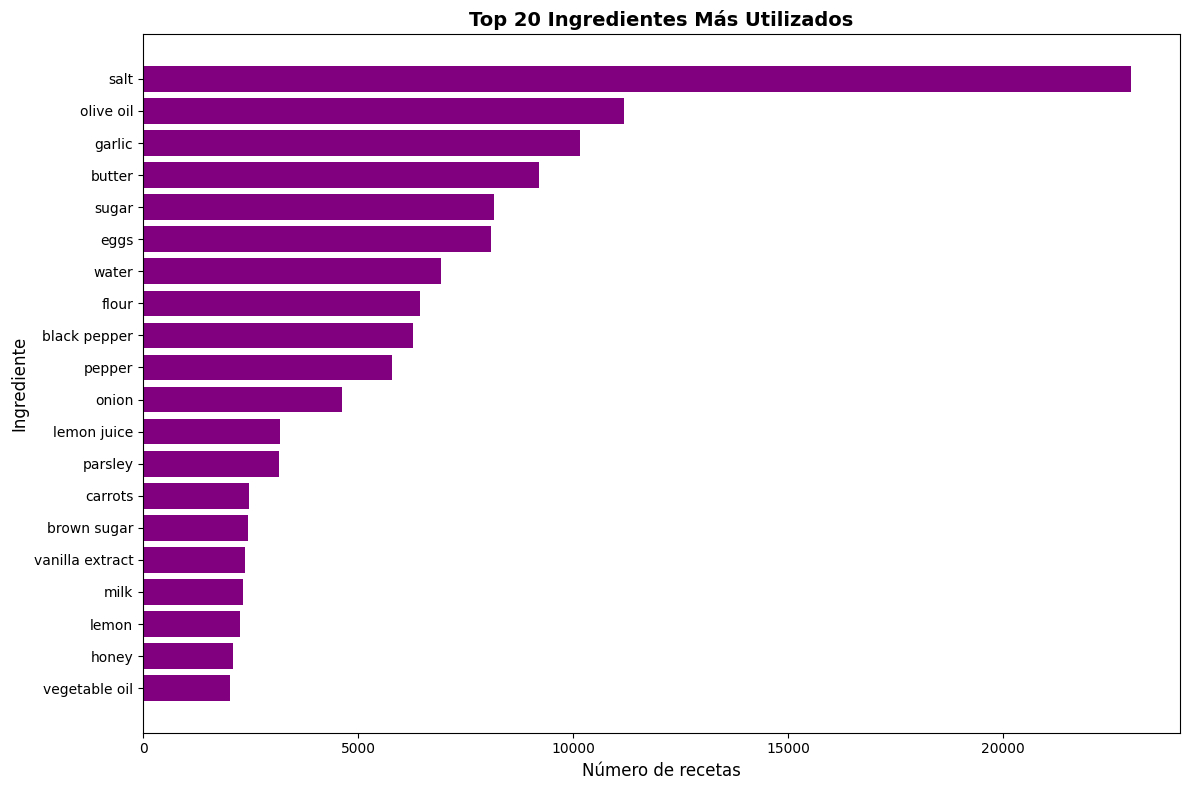

In [474]:
# Visualización de ingredientes más comunes
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 ingredientes para visualizar
top_20 = contador.most_common(20)
ingredientes_nombres = [item[0] for item in top_20]
ingredientes_conteos = [item[1] for item in top_20]

plt.figure(figsize=(12, 8))
plt.barh(ingredientes_nombres, ingredientes_conteos, color='purple')
plt.xlabel('Número de recetas', fontsize=12)
plt.ylabel('Ingrediente', fontsize=12)
plt.title('Top 20 Ingredientes Más Utilizados', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

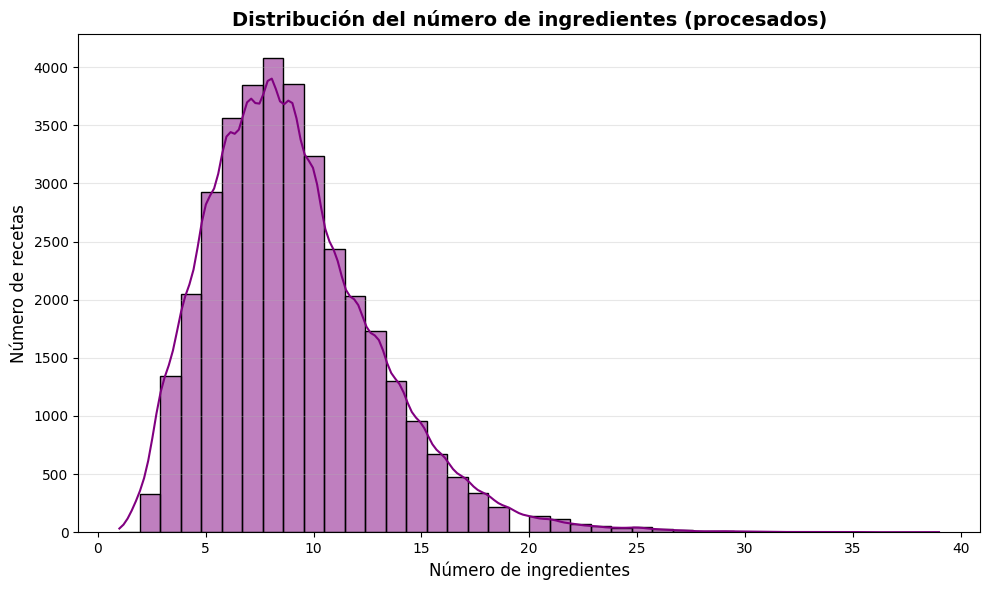

Media: 8.99 ingredientes
Mediana: 8 ingredientes
Rango: 1 - 39 ingredientes


In [475]:
# Histograma numero de ingredientes (limpios y procesados)

# Contar ingredientes limpios en cada receta
n_ingredients_list = df['ingredients_clean'].apply(len).tolist()

# Graficar
plt.figure(figsize=(10, 6))
sns.histplot(x=n_ingredients_list, bins=40, color="purple", kde=True)

plt.title("Distribución del número de ingredientes (procesados)", fontsize=14, fontweight='bold')
plt.xlabel("Número de ingredientes", fontsize=12)
plt.ylabel("Número de recetas", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Media: {sum(n_ingredients_list)/len(n_ingredients_list):.2f} ingredientes")
print(f"Mediana: {sorted(n_ingredients_list)[len(n_ingredients_list)//2]} ingredientes")
print(f"Rango: {min(n_ingredients_list)} - {max(n_ingredients_list)} ingredientes")


Este histograma muestra la distribución del número de ingredientes por receta.

Se puede observar que la mayoría de las recetas tienen un número relativamente normal de ingredientes, concentrándose en el rango de 5 a 12 ingredientes, siendo la media de unos 8-9 ingredientes.

## **6. Transformación y Procesamiento de Datos**

### 6.1. Limpieza Final de Columnas

#### 6.1.1. Campo `images`

Comprobamos si las urls del campo `image_url` están normalizadas y eliminamos aquellos campos con valores `character(0)` si las hay.

In [476]:
# Comrpobamos cuantas imágenes están bien normalizadas
TARGET_PREFIX = "http"

num_correctas = df["image_url"].dropna().str.startswith(TARGET_PREFIX).sum()

# Total filas
total_filas = len(df)

# Porcentaje correcto
porcentaje_correctas = num_correctas / total_filas * 100

print(f"Filas correctas: {num_correctas} / {total_filas} ({porcentaje_correctas:.2f}%)")


Filas correctas: 35933 / 35933 (100.00%)


In [477]:
# Booleano de filas correctas
mask_correct = df["image_url"].dropna().str.startswith(TARGET_PREFIX)

# Filas incorrectas
incorrectas = df.loc[~mask_correct, "image_url"]
print(incorrectas.head(10))
print(f"Total URLs incorrectas: {len(incorrectas)}")


Series([], Name: image_url, dtype: object)
Total URLs incorrectas: 0


In [478]:
print("Filas restantes:", len(df))
print("Ejemplo URLs:", df["image_url"].head(5).tolist())


Filas restantes: 35933
Ejemplo URLs: ['https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/0066d6f63e9b4ace21cfdb6a3579251a750aa31719be9b80e032f0fdfafb21c8/21126475.jpg', 'https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/000146940613626dc55ec857d59817f3fcdbb0e606192d4b3d6bf0f28f106ba1/21071596.jpg', 'https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/000273198e35300038a0b5833e294c23d746b2f59074cc5f235f7b8c47ce852f/20954046.jpg', 'https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/00040113c0b2836ed5b9f8a5036d459c20f90a6a950afadff79520371c8c7094/21054266.jpg', 'https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/0004e2c028f08b3a1f117735a5d8347c6084c4e42082f5a6dec3ef4bd1bb6341/20978031.jpg']


#### 6.1.2. Campo `recipe_names`

Limpiamos y normalizamos los nombres de las recetas.

In [479]:
def limpiar_name(text):
  """Limpia y normaliza el nombre de la receta, convirtiéndolo a minúsculas y eliminando caracteres no alfabéticos."""
  texto_limpio = text.lower()
  texto_limpio = re.sub(r'[^a-záéíóúñü\s]', '', texto_limpio)
  #texto_limpio = re.sub(r'[-]', ' ', texto_limpio)
  return texto_limpio

df["recipe_name"] = df["recipe_name"].apply(limpiar_name)

In [480]:
df["recipe_name"]

,recipe_name
0,classic cabbage slaw with grandmother shinns d...
1,black bean soup
2,eat for eight bucks tofu with tomatoes and cil...
4,the macaron frappé
5,cabbage au gratin
...,...
39441,spicy crock pot pinto bean chili
39442,asparagus cream pasta
39443,jamaican jerk seasoning blend
39444,moms brown gravy


In [481]:
df.shape

(35933, 14)

Tras la limpieza de los campos del dataset, nos quedamos con **37095 registros válidos** para el entrenamiento del modelo.

Almacenamos este dataset limpio para posibles usos futuros.

In [482]:
df.to_csv("recetas_limpio.csv", index=False)
print("Dataset guardado como recetas_limpio.csv")

Dataset guardado como recetas_limpio.csv


## **7. Ingeniería de Características: Ingredientes y Nutrición**

En esta sección transformaremos los datos crudos de ingredientes y la información nutricional en características más estructuradas y útiles para el modelo. Se realizan los siguientes pasos:

- **Normalización de campos**: Se limpian y estandarizan los `diet_labels` y `health_labels`(por ejemplo, a minúsculas y eliminando acentos o signos de puntuación).

- **Creación del campo diet_type** a partir de `diet_labels`, `health_labels` y umbrales nutricionales.

### 7.1. Normalización de campos




In [483]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean
0,classic cabbage slaw with grandmother shinns d...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tre...","[""salad""]","[""lunch/dinner""]",85.21,3.27,2.54,12.42,2.11,9.28,"[salt, water, cabbage, carrots, scallions, egg..."
1,black bean soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""soup""]","[""lunch/dinner""]",231.37,22.73,6.94,19.86,7.06,1.43,"[ham steak, olive oil, onion, garlic, water, c..."
2,eat for eight bucks tofu with tomatoes and cil...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",...","[""main course""]","[""lunch/dinner""]",410.94,25.31,25.65,25.85,6.17,0.00,"[firm tofu, canola oil, scallions, piece of gi..."
4,the macaron frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[""Vegetarian"",""Peanut-Free"",""Tree-Nut-Free"",""S...","[""desserts""]","[""snack""]",276.24,6.58,14.43,30.11,1.18,26.56,"[macaron, milk, vanilla ice cream, ice]"
5,cabbage au gratin,https://datahive-prod-dataset-products.s3.eu-c...,2.0,"[""Low-Carb""]","[""Vegetarian"",""Gluten-Free"",""Egg-Free"",""Peanut...","[""main course""]","[""lunch/dinner""]",339.30,11.28,26.48,10.18,2.17,4.13,"[cabbage, butter, onion, garlic, dried thyme, ..."


In [484]:
print("diet_labels:")
print(df['diet_labels'].head())
print("\nhealth_labels:")
print(df['health_labels'].head())
print("\ndish_type:")
print(df['dish_type'].head())
print("\nmeal_type:")
print(df['meal_type'].head())

diet_labels:
0                 ["Balanced"]
1               ["High-Fiber"]
2    ["High-Fiber","Low-Carb"]
4                           []
5                 ["Low-Carb"]
Name: diet_labels, dtype: object

health_labels:
0    ["Vegetarian","Gluten-Free","Peanut-Free","Tre...
1    ["Dairy-Free","Gluten-Free","Egg-Free","Peanut...
2    ["Vegan","Vegetarian","Dairy-Free","Egg-Free",...
4    ["Vegetarian","Peanut-Free","Tree-Nut-Free","S...
5    ["Vegetarian","Gluten-Free","Egg-Free","Peanut...
Name: health_labels, dtype: object

dish_type:
0          ["salad"]
1           ["soup"]
2    ["main course"]
4       ["desserts"]
5    ["main course"]
Name: dish_type, dtype: object

meal_type:
0    ["lunch/dinner"]
1    ["lunch/dinner"]
2    ["lunch/dinner"]
4           ["snack"]
5    ["lunch/dinner"]
Name: meal_type, dtype: object


In [485]:
def parse_list_string(list_string):
    """Convierte de forma segura una representación de string de una lista en una lista de Python."""
    if isinstance(list_string, list):
        return list_string
    try:
        # ast.literal_eval es más seguro que json.loads para strings potencialmente mal formados
        parsed_list = ast.literal_eval(list_string)
        if isinstance(parsed_list, list):
            return parsed_list
    except (ValueError, SyntaxError):
        pass # Si el parseo falla, retornar una lista vacía
    return [] # Retornar una lista vacía si el parseo falla o la entrada no es un string


columns_to_parse = ['diet_labels', 'health_labels', 'dish_type', 'meal_type']

for col in columns_to_parse:
    df[col] = df[col].apply(parse_list_string)

print("Tipos de datos después de parsear las listas:")
df[columns_to_parse].head()
df[columns_to_parse].info()

Tipos de datos después de parsear las listas:
<class 'pandas.core.frame.DataFrame'>
Index: 35933 entries, 0 to 39445
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   diet_labels    35933 non-null  object
 1   health_labels  35933 non-null  object
 2   dish_type      35933 non-null  object
 3   meal_type      35933 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


In [486]:
print("diet_labels:")
print(df['diet_labels'].head())
print("\nhealth_labels:")
print(df['health_labels'].head())
print("\ndish_type:")
print(df['dish_type'].head())
print("\nmeal_type:")
print(df['meal_type'].head())

diet_labels:
0                [Balanced]
1              [High-Fiber]
2    [High-Fiber, Low-Carb]
4                        []
5                [Low-Carb]
Name: diet_labels, dtype: object

health_labels:
0    [Vegetarian, Gluten-Free, Peanut-Free, Tree-Nu...
1    [Dairy-Free, Gluten-Free, Egg-Free, Peanut-Fre...
2    [Vegan, Vegetarian, Dairy-Free, Egg-Free, Tree...
4    [Vegetarian, Peanut-Free, Tree-Nut-Free, Soy-F...
5    [Vegetarian, Gluten-Free, Egg-Free, Peanut-Fre...
Name: health_labels, dtype: object

dish_type:
0          [salad]
1           [soup]
2    [main course]
4       [desserts]
5    [main course]
Name: dish_type, dtype: object

meal_type:
0    [lunch/dinner]
1    [lunch/dinner]
2    [lunch/dinner]
4           [snack]
5    [lunch/dinner]
Name: meal_type, dtype: object


In [ ]:
def normalize_label_list(label_list):
    """Normaliza una lista de etiquetas: minúsculas, divide por barras (/) para crear elementos separados."""
    if not isinstance(label_list, list):
        return []
    normalized_list = []
    for label in label_list:
        # Convertir a minúsculas y reemplazar guiones por espacios
        label = label.lower().replace('-', ' ')
        
        # Si contiene barras, dividir en múltiples elementos
        if '/' in label:
            parts = [part.strip() for part in label.split('/') if part.strip()]
            normalized_list.extend(parts)
        else:
            normalized_list.append(label.strip())
    
    # Eliminar duplicados manteniendo el orden
    seen = set()
    result = []
    for item in normalized_list:
        if item not in seen:
            seen.add(item)
            result.append(item)
    
    return result

columns_to_normalize = ['diet_labels', 'health_labels', 'dish_type', 'meal_type']

for col in columns_to_normalize:
    df[col] = df[col].apply(normalize_label_list)

print("Columnas de etiquetas normalizadas (minúsculas, valores con '/' divididos en elementos separados):")
df[columns_to_normalize].head()

Columnas de etiquetas normalizadas (minúsculas, guiones y barras reemplazados por espacios):


,diet_labels,health_labels,dish_type,meal_type
0,[balanced],"[vegetarian, gluten free, peanut free, tree nu...",[salad],[lunch dinner]
1,[high fiber],"[dairy free, gluten free, egg free, peanut fre...",[soup],[lunch dinner]
2,"[high fiber, low carb]","[vegan, vegetarian, dairy free, egg free, tree...",[main course],[lunch dinner]
4,[],"[vegetarian, peanut free, tree nut free, soy f...",[desserts],[snack]
5,[low carb],"[vegetarian, gluten free, egg free, peanut fre...",[main course],[lunch dinner]


### 7.2. Selección de recetas según `dish_type`

En este apartado excluiremos aquellas recetas como: bebidas alcoholicas, salsas o condimentos.

In [488]:
df["dish_type"].explode().unique().tolist()

['salad',
 'soup',
 'main course',
 'desserts',
 'biscuits and cookies',
 'drinks',
 'starter',
 'pancake',
 'alcohol cocktail',
 'condiments and sauces',
 'bread',
 'sandwiches',
 'cereals',
 'egg',
 'special occasions',
 'preserve',
 nan,
 'preps']

In [489]:
df_exploded = df.explode("dish_type")
preps_recipes = df_exploded[df_exploded["dish_type"] == "drinks"]
preps_recipes[['recipe_name', 'dish_type']]


,recipe_name,dish_type
7,sparkling berry lemonade,drinks
40,chocolatebanana protein smoothie recipes,drinks
43,berry kale smoothie recipes,drinks
59,hot chocolate,drinks
82,honey oat strawberry smoothie,drinks
...,...,...
39333,lemonberry mint smoomoo,drinks
39348,immune boosting smoothie a minute breakfast,drinks
39357,perfect arnold palmer,drinks
39420,iced coffee ca phe vietnam,drinks


In [490]:
# Quitamos aquellas recetas de categorias que no nos interesa, como las bebidas alcoholicas o las salsas
exclude = ["alcohol cocktail", "condiments and sauces"]

# Filtrar recetas que NO contengan estas categorías
df = df[~df["dish_type"].apply(lambda x: any(cat in x for cat in exclude) if isinstance(x, list) else False)]

print(f"Recetas después de filtrar: {len(df)}")

Recetas después de filtrar: 32948


In [491]:
# Comprobamos que ya no están
df["dish_type"].explode().unique().tolist()


['salad',
 'soup',
 'main course',
 'desserts',
 'biscuits and cookies',
 'drinks',
 'starter',
 'pancake',
 'bread',
 'sandwiches',
 'cereals',
 'egg',
 'special occasions',
 'preserve',
 nan,
 'preps']

### 7.3. Eliminación de categorías con valor `nan`

- `diet_labels`

In [492]:
unique_diet_values = df["diet_labels"].explode().unique().tolist()
unique_diet_values

['balanced',
 'high fiber',
 'low carb',
 nan,
 'low sodium',
 'low fat',
 'high protein']

In [493]:
# Eliminamos los valores nan
unique_diet_values = [x for x in unique_diet_values if str(x) != "nan"]
unique_diet_values

['balanced', 'high fiber', 'low carb', 'low sodium', 'low fat', 'high protein']

- `health_labels`

In [494]:
unique_health_labels = df["health_labels"].explode().unique().tolist()
unique_health_labels

['vegetarian',
 'gluten free',
 'peanut free',
 'tree nut free',
 'soy free',
 'fish free',
 'shellfish free',
 'dairy free',
 'egg free',
 'vegan',
 'paleo',
 nan,
 'low sugar']

In [495]:
# Eliminamos los valores nan
unique_health_labels = [x for x in unique_health_labels if str(x) != "nan"]
unique_health_labels

['vegetarian',
 'gluten free',
 'peanut free',
 'tree nut free',
 'soy free',
 'fish free',
 'shellfish free',
 'dairy free',
 'egg free',
 'vegan',
 'paleo',
 'low sugar']

### 7.4. Creación de la columna `diet_type`

Creamos un nuevo campo `diet_type` que combina:
1. Todas las etiquetas de `diet_labels`
2. Solo las etiquetas relevantes de `health_labels`: vegetarian, vegan, paleo
3. Dietas adicionales detectadas por condiciones nutricionales:
   - **keto**:
   ```
   protein_per_serving ≥ 20g AND fat_per_serving ≥ 25g AND carbs_per_serving ≤ 15g
   ```

In [496]:
def crear_diet_type(row):
    """
    Crea el campo diet_type combinando:
    1. Todos los valores de diet_labels
    2. Solo vegetarian, vegan, paleo de health_labels
    3. Detección de keto por condiciones nutricionales

    Retorna una lista sin duplicados.
    """
    diet_types = []

    # 1. Añadir todas las etiquetas de diet_labels
    if isinstance(row['diet_labels'], list):
        diet_types.extend(row['diet_labels'])

    # 2. Filtrar health_labels para incluir solo: vegetarian, vegan, paleo
    health_relevantes = ['vegetarian', 'vegan', 'paleo']
    if isinstance(row['health_labels'], list):
        for label in row['health_labels']:
            if label in health_relevantes:
                diet_types.append(label)

    # 3. Detectar dieta keto por condiciones nutricionales
    # Condiciones: protein ≥ 20g, fat ≥ 25g, carbs ≤ 15g
    try:
        protein = row.get('protein_per_serving', 0)
        fat = row.get('fat_per_serving', 0)
        carbs = row.get('carbs_per_serving', 0)

        if protein >= 20 and fat >= 25 and carbs <= 15:
            diet_types.append('keto')
    except:
        pass

    # Eliminar duplicados manteniendo el orden
    diet_types_unicos = []
    for dt in diet_types:
        if dt not in diet_types_unicos:
            diet_types_unicos.append(dt)

    return diet_types_unicos


# Aplicar la función para crear el campo diet_type
print("Creando campo diet_type...")
df['diet_type'] = df.apply(crear_diet_type, axis=1)

# Mostrar estadísticas
print(f"\n✓ Campo diet_type creado exitosamente")
print(f"\nTotal de recetas: {len(df)}")
print(f"Recetas con al menos una etiqueta diet_type: {(df['diet_type'].apply(len) > 0).sum()}")
print(f"Recetas sin etiquetas diet_type: {(df['diet_type'].apply(len) == 0).sum()}")

# Contar cuántas recetas tienen cada tipo de dieta
print("\n--- Distribución de tipos de dieta ---")
all_diet_types = []
for diet_list in df['diet_type']:
    all_diet_types.extend(diet_list)

diet_counts = pd.Series(all_diet_types).value_counts()
print(diet_counts)

# Mostrar ejemplos
print("\n--- Ejemplos de recetas con diet_type ---")
for i in range(min(5, len(df))):
    print(f"\nReceta {i+1}: {df.iloc[i]['recipe_name']}")
    print(f"  diet_labels: {df.iloc[i]['diet_labels']}")
    print(f"  health_labels (relevantes): {[h for h in df.iloc[i]['health_labels'] if h in ['vegetarian', 'vegan', 'paleo']]}")
    print(f"  Nutrición: protein={df.iloc[i]['protein_per_serving']:.1f}g, fat={df.iloc[i]['fat_per_serving']:.1f}g, carbs={df.iloc[i]['carbs_per_serving']:.1f}g")
    print(f"  → diet_type: {df.iloc[i]['diet_type']}")

Creando campo diet_type...

✓ Campo diet_type creado exitosamente

Total de recetas: 32948
Recetas con al menos una etiqueta diet_type: 31381
Recetas sin etiquetas diet_type: 1567

--- Distribución de tipos de dieta ---
vegetarian      19384
high fiber       9376
low carb         9365
low sodium       8772
vegan            7057
balanced         5456
low fat          4436
paleo            3561
keto             1363
high protein     1034
Name: count, dtype: int64

--- Ejemplos de recetas con diet_type ---

Receta 1: classic cabbage slaw with grandmother shinns dressing
  diet_labels: ['balanced']
  health_labels (relevantes): ['vegetarian']
  Nutrición: protein=3.3g, fat=2.5g, carbs=12.4g
  → diet_type: ['balanced', 'vegetarian']

Receta 2: black bean soup
  diet_labels: ['high fiber']
  health_labels (relevantes): []
  Nutrición: protein=22.7g, fat=6.9g, carbs=19.9g
  → diet_type: ['high fiber']

Receta 3: eat for eight bucks tofu with tomatoes and cilantro recipe
  diet_labels: ['high 

In [497]:
df.head()

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean,diet_type
0,classic cabbage slaw with grandmother shinns d...,https://datahive-prod-dataset-products.s3.eu-c...,6.0,[balanced],"[vegetarian, gluten free, peanut free, tree nu...",[salad],[lunch dinner],85.21,3.27,2.54,12.42,2.11,9.28,"[salt, water, cabbage, carrots, scallions, egg...","[balanced, vegetarian]"
1,black bean soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,[high fiber],"[dairy free, gluten free, egg free, peanut fre...",[soup],[lunch dinner],231.37,22.73,6.94,19.86,7.06,1.43,"[ham steak, olive oil, onion, garlic, water, c...",[high fiber]
2,eat for eight bucks tofu with tomatoes and cil...,https://datahive-prod-dataset-products.s3.eu-c...,4.0,"[high fiber, low carb]","[vegan, vegetarian, dairy free, egg free, tree...",[main course],[lunch dinner],410.94,25.31,25.65,25.85,6.17,0.00,"[firm tofu, canola oil, scallions, piece of gi...","[high fiber, low carb, vegan, vegetarian]"
4,the macaron frappé,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[vegetarian, peanut free, tree nut free, soy f...",[desserts],[snack],276.24,6.58,14.43,30.11,1.18,26.56,"[macaron, milk, vanilla ice cream, ice]",[vegetarian]
5,cabbage au gratin,https://datahive-prod-dataset-products.s3.eu-c...,2.0,[low carb],"[vegetarian, gluten free, egg free, peanut fre...",[main course],[lunch dinner],339.30,11.28,26.48,10.18,2.17,4.13,"[cabbage, butter, onion, garlic, dried thyme, ...","[low carb, vegetarian]"


In [498]:
# Verificar recetas detectadas como keto (que es inferido)
recetas_keto = df[df['diet_type'].apply(lambda x: 'keto' in x)]
print(f"\n--- Recetas detectadas como KETO ---")
print(f"Total de recetas keto: {len(recetas_keto)}")

if len(recetas_keto) > 0:
    print("\nEjemplos de recetas keto detectadas:")
    for i in range(min(3, len(recetas_keto))):
        row = recetas_keto.iloc[i]
        print(f"\n{i+1}. {row['recipe_name']}")
        print(f"   Protein: {row['protein_per_serving']:.1f}g (condición: ≥20)")
        print(f"   Fat: {row['fat_per_serving']:.1f}g (condición: ≥25)")
        print(f"   Carbs: {row['carbs_per_serving']:.1f}g (condición: ≤15)")
        print(f"   diet_type: {row['diet_type']}")
else:
    print("\nNOTA: No se detectaron recetas keto con las condiciones actuales.")


--- Recetas detectadas como KETO ---
Total de recetas keto: 1363

Ejemplos de recetas keto detectadas:

1. uova in purgatorio recipes
   Protein: 26.6g (condición: ≥20)
   Fat: 38.3g (condición: ≥25)
   Carbs: 14.5g (condición: ≤15)
   diet_type: ['low carb', 'keto']

2. southwest stuffed peppers recipe 
   Protein: 24.0g (condición: ≥20)
   Fat: 27.4g (condición: ≥25)
   Carbs: 14.7g (condición: ≤15)
   diet_type: ['low carb', 'keto']

3. cuminchile lamb kebabs with garlic yogurt
   Protein: 29.9g (condición: ≥20)
   Fat: 38.2g (condición: ≥25)
   Carbs: 8.3g (condición: ≤15)
   diet_type: ['low carb', 'keto']


In [499]:
# Observamos las recetas que no han sido clasificadas en ningún tipo de dieta
df[df['diet_type'].apply(lambda x: isinstance(x, list) and len(x) == 0)]


,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean,diet_type
13,crawfish fettuccine i,https://datahive-prod-dataset-products.s3.eu-c...,8.0,[],"[egg free, peanut free, tree nut free, soy fre...","[main course, starter]",[lunch dinner],600.02,27.79,32.65,48.45,2.70,3.89,"[butter, onion, bell pepper, celery, garlic, f...",[]
79,smoked trout cream cheese flagel,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[],"[egg free, peanut free, tree nut free, soy fre...",[main course],[lunch dinner],300.84,17.51,13.09,28.03,1.02,5.53,"[bagel, cream cheese, smoked trout, radishes]",[]
157,lobster ravioli,https://datahive-prod-dataset-products.s3.eu-c...,2.0,[],"[egg free, peanut free, tree nut free, soy fre...",[main course],[lunch dinner],657.74,35.05,15.75,93.77,4.47,0.00,"[flour, whole milk, frozen peas, fresh tarrago...",[]
162,popeyes sweet potato casserole,https://datahive-prod-dataset-products.s3.eu-c...,12.0,[],"[peanut free, soy free, fish free, shellfish f...",[main course],[lunch dinner],169.59,2.68,4.69,30.37,0.00,0.00,"[pecan pies, orange juice, sweet potato, marsh...",[]
166,chicken asparagus pasta recipe,https://datahive-prod-dataset-products.s3.eu-c...,2.0,[],"[egg free, peanut free, tree nut free, soy fre...",[main course],[lunch dinner],521.22,36.53,21.04,44.91,2.53,2.13,"[asparagus, canola oil, salt, pepper, fettucci...",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39350,creamy leek and potato soup,https://datahive-prod-dataset-products.s3.eu-c...,8.0,[],"[gluten free, egg free, peanut free, tree nut ...",[soup],[lunch dinner],180.70,2.29,13.88,13.31,1.54,3.25,"[butter, leeks, baking potato, broth, heavy cr...",[]
39359,salmon salad in english recipe,https://datahive-prod-dataset-products.s3.eu-c...,4.0,[],"[dairy free, gluten free, peanut free, tree nu...",[salad],[lunch dinner],408.03,22.28,25.34,20.68,0.00,0.00,"[salmon, eggs, white rice, onions, raw, rosema...",[]
39396,classic coquille st jacques on bacon pastry,https://datahive-prod-dataset-products.s3.eu-c...,8.0,[],"[egg free, peanut free, tree nut free, soy fre...",[main course],[lunch dinner],457.99,13.79,34.50,18.19,0.69,1.48,"[puff pastry, bacon, gruyere cheese, scallions...",[]
39422,barbecue chicken tacos with cabbage and queso,https://datahive-prod-dataset-products.s3.eu-c...,8.0,[],"[gluten free, peanut free, tree nut free, soy ...",[main course],[lunch dinner],305.86,12.15,18.88,22.39,2.55,8.91,"[olive oil, chicken thighs, ancho chile powder...",[]


In [500]:
# Eliminamos las recetas sin un tipo de dieta para no meter ruido/sesgos en el entrenamiento
df = df[df['diet_type'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

In [501]:
df[df['diet_type'].apply(lambda x: isinstance(x, list) and len(x) == 0)]

,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean,diet_type


In [502]:
df.shape

(31381, 15)

Nos quedamos con **32232 recetas** totales

## **8. Modelo de Recomendación Basado en Características Nutricionales (KNN)**

Para nuestra aplicación final, hemos decidido entrenar el dataset con el algoritmo supervisado **K-Nearest Neighbors (KNN)**, basándonos en las características nutricionales de cada receta.

### 8.1. Exploración y Preparación de Datos para KNN

In [503]:
df.describe()

,servings,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving
count,31381.000000,31381.000000,31381.000000,31381.000000,31381.000000,31381.000000,31381.000000
mean,6.540391,372.009329,15.854195,19.164994,35.498185,3.840622,9.180217
std,4.403301,288.510109,17.717204,20.067382,34.999234,4.237988,19.582980
min,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,188.890000,4.220000,6.520000,12.130000,0.870000,0.000000
50%,6.000000,281.130000,9.160000,13.440000,27.190000,2.610000,2.400000
75%,8.000000,468.250000,21.570000,24.440000,46.770000,5.570000,9.660000
max,24.000000,1999.700000,197.480000,198.220000,470.820000,123.550000,465.460000


In [504]:
df.sort_values(by="cals_per_serving", ascending=False)


,recipe_name,image_url,servings,diet_labels,health_labels,dish_type,meal_type,cals_per_serving,protein_per_serving,fat_per_serving,carbs_per_serving,fiber_per_serving,sugar_per_serving,ingredients_clean,diet_type
28774,basic buttermilk muffins recipe,https://datahive-prod-dataset-products.s3.eu-c...,1.0,[high fiber],"[vegetarian, peanut free, tree nut free, soy f...",[biscuits and cookies],[breakfast],1999.70,43.05,55.89,329.96,7.84,114.45,"[flour, sugar, baking soda, baking powder, sal...","[high fiber, vegetarian]"
24483,bbq addicts moink balls,https://datahive-prod-dataset-products.s3.eu-c...,2.0,[low carb],"[dairy free, gluten free, egg free, peanut fre...",[main course],[lunch dinner],1997.27,100.53,134.79,88.09,1.54,66.67,"[meatballs, bacon, brown sugar, cayenne pepper...",[low carb]
27085,copycat texas roadhouse rolls,https://datahive-prod-dataset-products.s3.eu-c...,2.0,[high fiber],"[vegetarian, peanut free, tree nut free, soy f...",[bread],[lunch dinner],1997.04,58.19,39.93,344.19,11.89,34.92,"[whole milk, sugar, yeast, eggs, butter, salt,...","[high fiber, vegetarian]"
577,cheddar biscuits,https://datahive-prod-dataset-products.s3.eu-c...,1.0,"[balanced, high fiber]","[vegetarian, peanut free, tree nut free, soy f...",[biscuits and cookies],[breakfast],1994.35,64.13,98.83,210.87,15.12,7.01,"[butter, water, butter, eggs, cheddar cheese]","[balanced, high fiber, vegetarian]"
25685,individual baked alaska,https://datahive-prod-dataset-products.s3.eu-c...,6.0,[],"[vegetarian, peanut free, tree nut free, soy f...",[desserts],[lunch dinner],1993.44,28.65,104.06,239.65,2.90,163.30,"[pound cake, vanilla ice cream, eggs, cream of...",[vegetarian]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32566,instant pot vegetable broth,https://datahive-prod-dataset-products.s3.eu-c...,12.0,"[low fat, low sodium]","[vegan, vegetarian, paleo, dairy free, gluten ...",[soup],[lunch dinner],0.60,0.02,0.00,0.14,0.04,0.00,"[carrots, onion, celery, garlic, black pepper,...","[low fat, low sodium, vegan, vegetarian, paleo]"
23523,firecracker milkshake,https://datahive-prod-dataset-products.s3.eu-c...,4.0,[low sodium],"[vegetarian, gluten free, egg free, peanut fre...",[desserts],[snack],0.52,0.01,0.03,0.06,0.00,0.05,"[vanilla ice cream, food coloring, food coloring]","[low sodium, vegetarian]"
39424,rose and jasmine tisane,https://datahive-prod-dataset-products.s3.eu-c...,3.0,"[low fat, low sodium]","[low sugar, vegan, vegetarian, paleo, dairy fr...",[drinks],[snack],0.28,0.01,0.00,0.06,0.00,0.00,"[rose petals, jasmine, water]","[low fat, low sodium, vegan, vegetarian, paleo]"
33533,beauty brew,https://datahive-prod-dataset-products.s3.eu-c...,1.0,"[low fat, low sodium]","[low sugar, vegan, vegetarian, paleo, dairy fr...",[drinks],[snack],0.06,0.00,0.00,0.02,0.00,0.00,"[tea, water]","[low fat, low sodium, vegan, vegetarian, paleo]"


 Preparamos los datos del DataFrame específicamente para el modelo de recomendación KNN.

In [505]:
# Creamos features adicionales para KNN
print("=== Creando features adicionales ===\n")

# 1. Ratios de macronutrientes
df['protein_ratio'] = (df['protein_per_serving'] * 4 / (df['cals_per_serving'] + 1)) * 100
df['fat_ratio'] = (df['fat_per_serving'] * 9 / (df['cals_per_serving'] + 1)) * 100
df['carbs_ratio'] = (df['carbs_per_serving'] * 4 / (df['cals_per_serving'] + 1)) * 100

# 2. Relación proteína/carbohidratos (importante para keto y low-carb)
df['protein_carb_ratio'] = df['protein_per_serving'] / (df['carbs_per_serving'] + 1)

# 3. Densidad calórica
df['calorie_density'] = df['cals_per_serving'] / (df['servings'] + 1)

# 4. Índice de fibra (fibra por 100 calorías)
df['fiber_index'] = (df['fiber_per_serving'] / (df['cals_per_serving'] + 1)) * 100

print("✓ Features adicionales creadas:")
print(f"  - protein_ratio, fat_ratio, carbs_ratio")
print(f"  - protein_carb_ratio")
print(f"  - calorie_density")
print(f"  - fiber_index")

# Mostrar ejemplos
print("\n--- Ejemplos de nuevas features ---")
print(df[['recipe_name', 'protein_ratio', 'fat_ratio', 'carbs_ratio', 'protein_carb_ratio']].head())

=== Creando features adicionales ===

✓ Features adicionales creadas:
  - protein_ratio, fat_ratio, carbs_ratio
  - protein_carb_ratio
  - calorie_density
  - fiber_index

--- Ejemplos de nuevas features ---
                                         recipe_name  protein_ratio  \
0  classic cabbage slaw with grandmother shinns d...      15.172254   
1                                    black bean soup      39.127254   
2  eat for eight bucks tofu with tomatoes and cil...      24.576395   
4                                 the macaron frappé       9.493580   
5                                  cabbage au gratin      13.258889   

   fat_ratio  carbs_ratio  protein_carb_ratio  
0  26.516645    57.626725            0.243666  
1  26.879546    34.186857            1.089645  
2  56.039715    25.100743            0.942644  
4  46.843890    43.442505            0.211508  
5  70.032324    11.965912            1.008945  


### 8.2. Entrenamiento del Modelo KNN

In [506]:
print("=== Entrenamiento Optimizado de KNN ===\n")

# 1. Actualizar features para incluir las nuevas
FEATURES = [
    "cals_per_serving",
    "fat_per_serving",
    "protein_per_serving",
    "carbs_per_serving",
    "fiber_per_serving",
    "sugar_per_serving",
    "protein_ratio",
    "protein_carb_ratio"
]

# Reiniciamos el índice de df
df = df.reset_index(drop=True)

# Creamos una nueva columna en el df llamada 'id' que serve como identificador único de cada receta
df["id"] = df.index

# 2. Preparar datos
X = df[FEATURES]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Buscar el mejor número de vecinos
print("Buscando número óptimo de vecinos...")
k_values = [5, 10, 15, 20, 25]
distances_mean = []

for k in k_values:
    knn_temp = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn_temp.fit(X_scaled)

    # Calcular distancia promedio
    distances, _ = knn_temp.kneighbors(X_scaled)
    distances_mean.append(distances.mean())
    print(f"  k={k:2d} → Distancia promedio: {distances.mean():.4f}")

# 4. Seleccionar el mejor k (usualmente donde la distancia empieza a estabilizarse)
best_k = k_values[np.argmin(np.gradient(distances_mean))]
print(f"\n✓ Mejor k seleccionado: {best_k}")

# 5. Entrenar modelo final con mejor k
knn = NearestNeighbors(
    n_neighbors=best_k,
    metric="euclidean",
    algorithm='auto'  # Deja que sklearn elija el mejor algoritmo
)

knn.fit(X_scaled)

print(f"\n✓ Modelo KNN entrenado exitosamente")
print(f"  - Número de vecinos: {best_k}")
print(f"  - Features utilizadas: {len(FEATURES)}")
print(f"  - Recetas en el modelo: {len(df)}")

# 6. Validación del modelo
print("\n--- Validación del Modelo ---")
sample_indices = np.random.choice(len(X_scaled), size=100, replace=False)
X_sample = X_scaled[sample_indices]

distances, indices = knn.kneighbors(X_sample)

print(f"Distancia promedio a vecinos más cercanos: {distances[:, 1:].mean():.4f}")
print(f"Desviación estándar: {distances[:, 1:].std():.4f}")
print(f"Distancia mínima: {distances[:, 1:].min():.4f}")
print(f"Distancia máxima: {distances[:, 1:].max():.4f}")

=== Entrenamiento Optimizado de KNN ===

Buscando número óptimo de vecinos...
  k= 5 → Distancia promedio: 0.2409
  k=10 → Distancia promedio: 0.3220
  k=15 → Distancia promedio: 0.3688
  k=20 → Distancia promedio: 0.4026
  k=25 → Distancia promedio: 0.4296

✓ Mejor k seleccionado: 25

✓ Modelo KNN entrenado exitosamente
  - Número de vecinos: 25
  - Features utilizadas: 8
  - Recetas en el modelo: 31381

--- Validación del Modelo ---
Distancia promedio a vecinos más cercanos: 0.3933
Desviación estándar: 0.3104
Distancia mínima: 0.0000
Distancia máxima: 2.0366


### 8.3. Evaluación del modelo

In [507]:
print("=== Evaluación del Modelo ===\n")

# 1. Diversidad de recomendaciones
def evaluar_diversidad(n_tests=50):
    """Evalúa la diversidad de las recomendaciones"""
    diet_types_recomendados = []
    dish_types_recomendados = []

    for _ in range(n_tests):
        # Seleccionar receta aleatoria
        idx = np.random.randint(0, len(df))
        recipe_features = X_scaled[idx].reshape(1, -1)

        # Obtener recomendaciones
        _, indices = knn.kneighbors(recipe_features, n_neighbors=10)

        # Recopilar tipos
        for i in indices[0][1:]:  # Excluir la misma receta
            diet_types_recomendados.extend(df.iloc[i]['diet_type'])
            # dish_type es una lista, así que hay que aplanarla también
            dish_type_value = df.iloc[i]['dish_type']
            if isinstance(dish_type_value, list):
                dish_types_recomendados.extend(dish_type_value)
            else:
                dish_types_recomendados.append(dish_type_value)

    diet_diversity = len(set(diet_types_recomendados))
    dish_diversity = len(set(dish_types_recomendados))

    print(f"Diversidad de tipos de dieta: {diet_diversity}")
    print(f"Diversidad de tipos de plato: {dish_diversity}")
    print(f"\nTop 5 dietas recomendadas:")
    print(pd.Series(diet_types_recomendados).value_counts().head())
    print(f"\nTop 5 tipos de plato recomendados:")
    print(pd.Series(dish_types_recomendados).value_counts().head())

evaluar_diversidad()

# 2. Coherencia nutricional
def evaluar_coherencia(n_tests=20):
    """Evalúa si las recomendaciones son nutricionalmente coherentes"""
    print("\n--- Coherencia Nutricional ---\n")

    desviaciones = []

    for test_num in range(n_tests):
        idx = np.random.randint(0, len(df))
        recipe = df.iloc[idx]
        recipe_features = X_scaled[idx].reshape(1, -1)

        _, indices = knn.kneighbors(recipe_features, n_neighbors=6)

        # Calcular desviación en calorías
        cals_original = recipe['cals_per_serving']
        cals_recomendadas = df.iloc[indices[0][1:]]['cals_per_serving'].values

        desviacion = np.abs(cals_recomendadas - cals_original).mean()
        desviacion_pct = (desviacion / cals_original) * 100
        desviaciones.append(desviacion_pct)

        if test_num < 3:  # Mostrar solo los primeros 3 ejemplos
            print(f"Receta: {recipe['recipe_name']}")
            print(f"  Calorías: {cals_original:.0f} kcal")
            print(f"  Desviación promedio: {desviacion:.0f} kcal ({desviacion_pct:.1f}%)")
            print(f"  Calorías recomendadas: {cals_recomendadas.min():.0f} - {cals_recomendadas.max():.0f} kcal")
            print()

    # Estadísticas generales
    print(f"--- Resumen de Coherencia ---")
    print(f"Desviación promedio general: {np.mean(desviaciones):.1f}%")
    print(f"Desviación mínima: {np.min(desviaciones):.1f}%")
    print(f"Desviación máxima: {np.max(desviaciones):.1f}%")
    print(f"Desviación mediana: {np.median(desviaciones):.1f}%")

evaluar_coherencia()

# 3. Análisis de similitud por tipo de dieta
def evaluar_similitud_dieta(n_tests=50):
    """Evalúa si las recetas recomendadas mantienen el tipo de dieta similar"""
    print("\n--- Similitud en Tipos de Dieta ---\n")

    similitudes = []

    for _ in range(n_tests):
        idx = np.random.randint(0, len(df))
        recipe = df.iloc[idx]
        recipe_features = X_scaled[idx].reshape(1, -1)

        _, indices = knn.kneighbors(recipe_features, n_neighbors=6)

        # Obtener dietas originales y recomendadas
        dieta_original = set(recipe['diet_type']) if isinstance(recipe['diet_type'], list) else set()

        # Contar cuántas recomendaciones comparten al menos una etiqueta
        matches = 0
        for i in indices[0][1:]:
            dieta_rec = df.iloc[i]['diet_type']
            dieta_recomendada = set(dieta_rec) if isinstance(dieta_rec, list) else set()
            if dieta_original & dieta_recomendada:  # Intersección
                matches += 1

        similitud = (matches / 5) * 100  # 5 recomendaciones
        similitudes.append(similitud)

    print(f"Similitud promedio en tipos de dieta: {np.mean(similitudes):.1f}%")
    print(f"Porcentaje de recomendaciones con al menos 1 dieta en común: {np.mean(similitudes):.1f}%")
    print(f"\nDistribución:")
    print(f"  - 100% similar: {(np.array(similitudes) == 100).sum()} casos")
    print(f"  - 80-99% similar: {((np.array(similitudes) >= 80) & (np.array(similitudes) < 100)).sum()} casos")
    print(f"  - 60-79% similar: {((np.array(similitudes) >= 60) & (np.array(similitudes) < 80)).sum()} casos")
    print(f"  - <60% similar: {(np.array(similitudes) < 60).sum()} casos")

evaluar_similitud_dieta()

# 4. Análisis de distribución de macronutrientes
def analizar_macros_recomendaciones(n_tests=30):
    """Analiza la distribución de macronutrientes en las recomendaciones"""
    print("\n--- Análisis de Macronutrientes en Recomendaciones ---\n")

    desv_protein = []
    desv_fat = []
    desv_carbs = []

    for _ in range(n_tests):
        idx = np.random.randint(0, len(df))
        recipe = df.iloc[idx]
        recipe_features = X_scaled[idx].reshape(1, -1)

        _, indices = knn.kneighbors(recipe_features, n_neighbors=6)

        # Calcular desviaciones para cada macronutriente
        protein_orig = recipe['protein_per_serving']
        fat_orig = recipe['fat_per_serving']
        carbs_orig = recipe['carbs_per_serving']

        protein_rec = df.iloc[indices[0][1:]]['protein_per_serving'].values
        fat_rec = df.iloc[indices[0][1:]]['fat_per_serving'].values
        carbs_rec = df.iloc[indices[0][1:]]['carbs_per_serving'].values

        # Desviación porcentual
        desv_protein.append((np.abs(protein_rec - protein_orig).mean() / (protein_orig + 1)) * 100)
        desv_fat.append((np.abs(fat_rec - fat_orig).mean() / (fat_orig + 1)) * 100)
        desv_carbs.append((np.abs(carbs_rec - carbs_orig).mean() / (carbs_orig + 1)) * 100)

    print(f"Desviación promedio en Proteínas: {np.mean(desv_protein):.1f}%")
    print(f"Desviación promedio en Grasas: {np.mean(desv_fat):.1f}%")
    print(f"Desviación promedio en Carbohidratos: {np.mean(desv_carbs):.1f}%")
    print(f"\nEl modelo mantiene mejor la similitud en: ", end="")
    mejor = min([(np.mean(desv_protein), 'Proteínas'),
                 (np.mean(desv_fat), 'Grasas'),
                 (np.mean(desv_carbs), 'Carbohidratos')],
                key=lambda x: x[0])
    print(f"{mejor[1]} ({mejor[0]:.1f}% desviación)")

analizar_macros_recomendaciones()

=== Evaluación del Modelo ===

Diversidad de tipos de dieta: 9
Diversidad de tipos de plato: 14

Top 5 dietas recomendadas:
vegetarian    312
low carb      140
low sodium    125
high fiber    123
vegan         114
Name: count, dtype: int64

Top 5 tipos de plato recomendados:
main course    195
desserts        80
salad           45
starter         33
bread           25
Name: count, dtype: int64

--- Coherencia Nutricional ---

Receta: breakfast sausage casserole recipe  
  Calorías: 271 kcal
  Desviación promedio: 6 kcal (2.3%)
  Calorías recomendadas: 261 - 276 kcal

Receta: chickpea salad sandwich
  Calorías: 277 kcal
  Desviación promedio: 21 kcal (7.7%)
  Calorías recomendadas: 237 - 279 kcal

Receta: pan con tomate tomato bread
  Calorías: 161 kcal
  Desviación promedio: 11 kcal (6.9%)
  Calorías recomendadas: 166 - 181 kcal

--- Resumen de Coherencia ---
Desviación promedio general: 7.3%
Desviación mínima: 2.3%
Desviación máxima: 19.3%
Desviación mediana: 6.4%

--- Similitud en Ti

In [508]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31381 entries, 0 to 31380
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   recipe_name          31381 non-null  object 
 1   image_url            31381 non-null  object 
 2   servings             31381 non-null  float64
 3   diet_labels          31381 non-null  object 
 4   health_labels        31381 non-null  object 
 5   dish_type            31381 non-null  object 
 6   meal_type            31381 non-null  object 
 7   cals_per_serving     31381 non-null  float64
 8   protein_per_serving  31381 non-null  float64
 9   fat_per_serving      31381 non-null  float64
 10  carbs_per_serving    31381 non-null  float64
 11  fiber_per_serving    31381 non-null  float64
 12  sugar_per_serving    31381 non-null  float64
 13  ingredients_clean    31381 non-null  object 
 14  diet_type            31381 non-null  object 
 15  protein_ratio        31381 non-null 

### 8.4. Guardar Modelos Entrenados

In [509]:
dump(df, "df_recetas.joblib")
dump(scaler, "scaler.joblib")
dump(knn, "knn.joblib")

['knn.joblib']

### 8.5. Pruebas del modelo

Se ha probado el funcionamiento del modelo en la app web:

<https://smarteat-ml-rec.streamlit.app/>

## Conclusiones

Tras varias pruebas, se concluye que el modelo funciona correctamente, ofreciendo resultados coherentes y consistentes. El algoritmo **KNN** identifica de forma fiable similitudes según el tipo de dieta y la distribución de macronutrientes.

Las inconsistencias detectadas se deben principalmente a la calidad del dataset, ya sea por falta de información o por datos mal introducidos por los usuarios de Foods.com. Con un conjunto de datos más amplio, mejor clasificado y correctamente insertado, el modelo podría ofrecer recomendaciones más precisas y de mayor calidad.

# 🥳🎉🪅